# Palm Fruit Ripeness Classification — ResNet18 (PyTorch/torchvision → ONNX → TFLite)

This notebook trains ResNet18 with ImageNet pretrained weights via **PyTorch + torchvision**,
following the same fair-comparison protocol as MobileNetV2, MobileNetV3, and ShuffleNetV2
defined in `Model.md §6`.

### Why ResNet18
ResNet18 is a well-established baseline with strong ImageNet pretrained weights, widely
benchmarked on small datasets. It offers a meaningful accuracy/size datapoint between
the lightweight ShuffleNetV2 (~2.3M params) and heavier MobileNetV2 (~3.4M params):
ResNet18 has ~11.7M parameters but benefits from robust residual skip connections that
improve gradient flow and converge reliably on small datasets.

### What is kept identical to MobileNetV2 (fair comparison)
| Parameter | Value | Source |
|---|---|---|
| Dataset split | 80/20, SEED=42 | `Model.md §6.1` |
| Image size | 224×224 | Baseline |
| Batch size | 32 | Baseline |
| Augmentation | Flip/Rotate/Zoom | Baseline |
| Phase 1 epochs | 30, LR=1e-4 | Baseline |
| Phase 2 epochs | 15, LR=1e-5 | Baseline |
| EarlyStopping patience | Phase1=7, Phase2=5 | Baseline |
| ReduceLROnPlateau | factor=0.5, patience=4 | Baseline |
| Classifier head | Dropout→Dense(128)→BN→Dropout→Softmax | Baseline |
| Test set | 180 images, evaluated once | `Model.md §6.1` |
| INT8 gate | <2% relative drop | `Model.md §6.3` |

### Framework & preprocessing
- Model: `torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)`
- Preprocessing: ImageNet normalisation (`mean=[0.485,0.456,0.406]`, `std=[0.229,0.224,0.225]`)
- `preprocessing_family`: `imagenet_torchvision` — same runtime branch as ShuffleNetV2

### ResNet18 architecture key differences vs ShuffleNetV2
| | ShuffleNetV2 x1.0 | ResNet18 |
|---|---|---|
| Params | ~2.3M | ~11.7M |
| Block type | Channel-split + shuffle | Residual skip connection |
| Head input features | 1024 | 512 |
| Phase 2 unfreeze | stage4 + conv5 | layer4 + fc |
| ONNX file suffix | shufflenetv2 | resnet18 |

### Notebook structure (mirrors ShuffleNetV2Onnx exactly)
```
Cell 1   Dependency installation
Cell 2   Imports & configuration
Cell 3   Filesystem counts & class names
Cell 4   Preprocessing transforms (ImageNet normalisation)
Cell 5   Dataset loading with 80/20 split (SubsetWithTransform + Windows fix)
Cell 6   Build model — ResNet18 + custom head + Phase 1 freeze
Cell 7   Training utilities (EarlyStopping, train/eval loop, print_epoch)
Cell 8   Training — Phase 1 (frozen backbone) + Phase 2 (fine-tune)
Cell 9   ONNX export (ModelWithSoftmax wrapper, opset 13, static batch)
Cell 10  ONNX Runtime pre-validation (5-sample gate, Δ < 1e-4)
Cell 11  onnxsim + onnx2tf → FP32 / FP16 / INT8 TFLite
Cell 12  FP32 TFLite artifact naming
Cell 13  FP16 TFLite artifact naming
Cell 14  INT8 TFLite via onnx2tf -oiqt
Cell 15  Labels JSON + manifest
Cell 16  TFLite accuracy validation (FP32 vs INT8, INT8 gate)
Cell 17  Confusion matrices + metrics bar chart
Cell 18  Excel report
Cell 19  Experiment log (schema-safe append)
Cell 20  Deployment summary & runtime command reference
```


In [ ]:
# Cell 1 — Dependency installation
# Run once. Restart kernel after this cell completes.
# Pinned versions prevent the version-matrix failures seen in MobileNetV3 conversion.
# (Reference: Record.md — MobileNetV3 Keras3 deserialisation failure)

import subprocess, sys

packages = [
    "torch==2.6.0+cu124",         # Stable 2026 release
    "torchvision==0.21.0+cu124",   # Exact match for torch 2.6.0
    "timm==1.0.12",               # Latest stable for MobileNetV2
    "onnx==1.17.0",               # Corrected spelling 'onnx'
    "onnxscript",                 # Required by torch.onnx new exporter path (torch>=2.6)
    "onnxsim",                    # ONNX simplifier before onnx2tf conversion
    "onnx2tf",                    # Modern ONNX -> TFLite/LiteRT conversion bridge
    "onnxruntime-gpu==1.20.0",    # GPU-accelerated runtime
    "onnx-tf==1.10.0",
    "onnxoptimizer==0.3.13",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "pandas",
    "openpyxl",
]

print("Installing dependencies (this may take several minutes on first run)...")
for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    status = "OK" if result.returncode == 0 else "FAILED"
    print(f"  [{status}] {pkg}")
    if result.returncode != 0:
        print(f"         stderr: {result.stderr[-300:]}")

print("\nAll packages processed.")
print("If any FAILED: install manually then re-run.")
print("After first successful run, comment out this cell to speed up re-runs.")


Installing dependencies (this may take several minutes on first run)...
  [FAILED] torch==2.6.0+cu124
         stderr: ERROR: Could not find a version that satisfies the requirement torch==2.6.0+cu124 (from versions: 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==2.6.0+cu124

  [FAILED] torchvision==0.21.0+cu124
         stderr: 7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Could not find a version that satisfies the requirement torchvision==0.21.0+cu124 (from versions: 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0, 0.26.0)
ERROR: No matching distribution found for torchvision==0.21.0+cu124

  [OK] timm==1.0.12


In [ ]:
# Cell 2 — Imports & configuration
# All protocol-critical constants are here.
# Values marked [MUST MATCH BASELINE] must not change between model experiments.

import os
import csv
import json
import datetime
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder

from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42  # [MUST MATCH BASELINE]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Dataset paths ───────────────────────────────────────────────────────────
DATASET_ROOT = os.getenv(
    "DATASET_ROOT",
    r"C:\Users\jeffy\Documents\PSM\Dataset1"
)
TRAIN_ROOT = os.getenv("TRAIN_ROOT", os.path.join(DATASET_ROOT, "Train"))
TEST_ROOT  = os.getenv("TEST_ROOT",  os.path.join(DATASET_ROOT, "Test"))

# ── Image / loader settings [MUST MATCH BASELINE] ───────────────────────────
IMG_SIZE    = (224, 224)   # H×W — identical to MobileNetV2/ShuffleNetV2
BATCH_SIZE  = 32           # identical to baseline
VAL_SPLIT   = 0.2          # 80/20 split — identical to baseline
NUM_WORKERS = 2            # set 0 on Windows if errors occur

# ── ResNet18 model identity ──────────────────────────────────────────────────
# torchvision.models.resnet18 — ~11.7M params, ImageNet pretrained
# No timm dependency needed: torchvision is already in the stack
MODEL_NAME = "resnet18"    # used for ONNX filename and logging
VARIANT    = "IMAGENET1K_V1"  # pretrained weight tag

# ── Training hyperparameters [MUST MATCH BASELINE] ───────────────────────────
EPOCHS            = 30    # Phase 1 (frozen backbone) — same as MobileNetV2
FINE_TUNE_EPOCHS  = 15    # Phase 2 (partial unfreeze) — same as MobileNetV2
LR_PHASE1         = 1e-4  # Phase 1 Adam LR — same as MobileNetV2
LR_PHASE2         = 1e-5  # Phase 2 Adam LR — same as MobileNetV2
LR_MIN_PHASE1     = 1e-6  # ReduceLROnPlateau min_lr — same as MobileNetV2
LR_MIN_PHASE2     = 1e-7  # Phase 2 min_lr — same as MobileNetV2
PATIENCE_TRAIN    = 7     # EarlyStopping patience Phase 1 — same as MobileNetV2
PATIENCE_FT       = 5     # EarlyStopping patience Phase 2 — same as MobileNetV2
RLROP_PATIENCE    = 4     # ReduceLROnPlateau patience Phase 1 — same as MobileNetV2
RLROP_PATIENCE_FT = 3     # ReduceLROnPlateau patience Phase 2 — same as MobileNetV2
DROPOUT_RATE      = 0.3   # Classifier head dropout — same as MobileNetV2

# ── Run mode flags (mirror MobileNetV2 DO_* pattern) ────────────────────────
DO_SMOKE     = False   # True → 1-epoch pipeline sanity check only
DO_TRAIN     = True    # True → run Phase 1 (frozen backbone training)
DO_FINE_TUNE = True    # True → run Phase 2 (partial unfreeze fine-tuning)
SMOKE_STEPS  = 50      # batches to run during smoke test

# ── Output directories ───────────────────────────────────────────────────────
MODEL_DIR  = "saved_models"
MODELS_DIR = "models"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version   : {torch.__version__}")
print(f"torchvision model : {MODEL_NAME} ({VARIANT})")
print(f"Device            : {DEVICE}")
if torch.cuda.is_available():
    print(f"CUDA device       : {torch.cuda.get_device_name(0)}")
print(f"Timestamp         : {TIMESTAMP}")
print(f"TRAIN_ROOT        : {TRAIN_ROOT}")
print(f"TEST_ROOT         : {TEST_ROOT}")
print(f"SEED              : {SEED}  [must match MobileNetV2]")
print(f"IMG_SIZE          : {IMG_SIZE}  [must match MobileNetV2]")
print(f"BATCH_SIZE        : {BATCH_SIZE}  [must match MobileNetV2]")
print(f"VAL_SPLIT         : {VAL_SPLIT}  [must match MobileNetV2]")


PyTorch version   : 2.11.0+cu128
torchvision model : resnet18 (IMAGENET1K_V1)
Device            : cuda
CUDA device       : NVIDIA GeForce RTX 4060 Laptop GPU
Timestamp         : 20260501_170624
TRAIN_ROOT        : C:\Users\jeffy\Documents\PSM\Dataset1\Train
TEST_ROOT         : C:\Users\jeffy\Documents\PSM\Dataset1\Test
SEED              : 42  [must match MobileNetV2]
IMG_SIZE          : (224, 224)  [must match MobileNetV2]
BATCH_SIZE        : 32  [must match MobileNetV2]
VAL_SPLIT         : 0.2  [must match MobileNetV2]


In [2]:
# Cell 3 — Filesystem counts & class names
# Identical count_images() helper from MobileNetV2 notebook.
# ImageFolder sorts classes alphabetically — same order as TF's
# image_dataset_from_directory — ensuring class indices match across models.

def count_images(root):
    """Count image files per class subfolder. Returns (dict, total)."""
    counts = {}
    total  = 0
    if not os.path.exists(root):
        return counts, total
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            files = [f for f in os.listdir(p)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            counts[cls] = len(files)
            total += len(files)
    return counts, total

train_counts, train_total = count_images(TRAIN_ROOT)
test_counts,  test_total  = count_images(TEST_ROOT)

print("Filesystem counts")
print(f"  Train : {train_counts}  =>  {train_total} images")
print(f"  Test  : {test_counts}   =>  {test_total} images")

if train_total == 0:
    raise FileNotFoundError(
        f"No training images found under {TRAIN_ROOT}\n"
        "Check DATASET_ROOT / TRAIN_ROOT environment variable or path."
    )

# Derive class names from sorted subfolder names (mirrors ImageFolder behaviour)
class_names = sorted(
    cls for cls in os.listdir(TRAIN_ROOT)
    if os.path.isdir(os.path.join(TRAIN_ROOT, cls))
)
num_classes = len(class_names)

n_val   = int(train_total * VAL_SPLIT)
n_train = train_total - n_val

print(f"\nDetected classes : {class_names}  ({num_classes} classes)")
print(f"Train images     : {n_train}  (~{100*(1-VAL_SPLIT):.0f}%)")
print(f"Val   images     : {n_val}    (~{100*VAL_SPLIT:.0f}%)")
print(f"Test  images     : {test_total}")
print(f"\nClass → index mapping (alphabetical, matches TF/ImageFolder):")
for idx, name in enumerate(class_names):
    print(f"  {idx}: {name}")


Filesystem counts
  Train : {'Overripe': 400, 'Ripe': 400, 'Underripe': 400}  =>  1200 images
  Test  : {'Overripe': 60, 'Ripe': 60, 'Underripe': 60}   =>  180 images

Detected classes : ['Overripe', 'Ripe', 'Underripe']  (3 classes)
Train images     : 960  (~80%)
Val   images     : 240    (~20%)
Test  images     : 180

Class → index mapping (alphabetical, matches TF/ImageFolder):
  0: Overripe
  1: Ripe
  2: Underripe


In [3]:
# Cell 4 — Preprocessing transforms
#
# ResNet18 was pretrained on ImageNet using the same normalisation as all
# standard torchvision models:
#   mean = [0.485, 0.456, 0.406]
#   std  = [0.229, 0.224, 0.225]
#
# This is IDENTICAL to the ShuffleNetV2 notebook — so the preprocessing_family
# "imagenet_torchvision" applies to both. The same runtime branch in
# pi_inference.py and api/app.py handles ResNet18 as well.
#
# AUGMENTATION POLICY [MUST MATCH MobileNetV2]:
#   MobileNetV2 uses: RandomFlip(horizontal) + RandomRotation(0.15 rad)
#                     + RandomZoom(0.1)
#   This notebook matches: RandomHorizontalFlip() + RandomRotation(15°)
#                          + RandomResizedCrop(scale=0.9-1.0)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transform — augmentation active
train_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.RandomHorizontalFlip(),                         # mirrors RandomFlip("horizontal")
    T.RandomRotation(degrees=15),                     # mirrors RandomRotation(0.15 rad)
    T.RandomResizedCrop(224, scale=(0.9, 1.0)),       # mirrors RandomZoom(0.1)
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation / test transform — NO augmentation
val_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Transforms defined.")
print(f"  Train : Resize(256) → CenterCrop(224) → HFlip → Rotate(±15°) → RandResizedCrop(0.9-1.0) → ToTensor → Normalize")
print(f"  Val   : Resize(256) → CenterCrop(224) → ToTensor → Normalize")
print(f"  ImageNet mean : {IMAGENET_MEAN}")
print(f"  ImageNet std  : {IMAGENET_STD}")
print(f"  preprocessing_family : imagenet_torchvision")
print()
print("IMPORTANT: runtime inference MUST apply the same normalisation.")
print("Use --preprocess-family imagenet_torchvision in pi_inference.py and api/app.py.")


Transforms defined.
  Train : Resize(256) → CenterCrop(224) → HFlip → Rotate(±15°) → RandResizedCrop(0.9-1.0) → ToTensor → Normalize
  Val   : Resize(256) → CenterCrop(224) → ToTensor → Normalize
  ImageNet mean : [0.485, 0.456, 0.406]
  ImageNet std  : [0.229, 0.224, 0.225]
  preprocessing_family : imagenet_torchvision

IMPORTANT: runtime inference MUST apply the same normalisation.
Use --preprocess-family imagenet_torchvision in pi_inference.py and api/app.py.


In [4]:
# Cell 5 — Dataset loading with 80/20 split
#
# ── Windows multiprocessing fix ──────────────────────────────────────────────
# On Windows, DataLoader uses the 'spawn' multiprocessing start method.
# Dataset classes defined interactively in a Jupyter notebook cell are NOT
# picklable by spawn workers — they live in __main__ but workers start fresh
# and cannot find the class definition, causing a silent 30–120s hang before
# timing out and falling back to single-threaded loading.
#
# Fix: NUM_WORKERS = 0 on Windows (multiprocessing.cpu_count is irrelevant here).
#      On Linux (fork method), workers > 0 would work fine.
#
# The alternative fix — saving SubsetWithTransform to a .py file and importing
# it — is avoided here to keep the notebook self-contained.
#
# ── Val transform leakage fix ─────────────────────────────────────────────────
# random_split() shares the underlying ImageFolder between train and val.
# SubsetWithTransform bypasses the shared dataset's transform by loading the
# raw PIL image directly and applying its own transform independently.
# This prevents augmentation from leaking into the validation set.

import os
import platform
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from PIL import Image

# ── Windows-safe worker count ─────────────────────────────────────────────────
# spawn method on Windows cannot pickle notebook-defined Dataset classes.
# Use 0 workers (main-process loading) on Windows; Linux can use NUM_WORKERS.
_ON_WINDOWS = platform.system() == "Windows"
SAFE_NUM_WORKERS = 0 if _ON_WINDOWS else NUM_WORKERS

if _ON_WINDOWS and NUM_WORKERS > 0:
    print(f"Windows detected: overriding num_workers {NUM_WORKERS} → 0")
    print("  Reason: spawn multiprocessing cannot pickle notebook-defined Dataset.")
    print("  Training will use main-process data loading (correct, slightly slower).")
    print("  GPU training speed is not significantly affected — GPU is the bottleneck.")
else:
    print(f"num_workers: {SAFE_NUM_WORKERS}")


class SubsetWithTransform(Dataset):
    """
    Wraps a Subset and applies a specific transform, bypassing the underlying
    dataset's own transform. This is the fix for val-transform leakage when
    train and val subsets share the same ImageFolder object.

    Design note: loads raw PIL images via dataset.loader(path) instead of
    calling dataset[global_idx] (which would apply the dataset's own transform
    and defeat the purpose of this wrapper).
    """
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform
        self.dataset   = subset.dataset      # underlying ImageFolder reference
        # Cache the loader function once — avoids get_image_backend() overhead
        self._loader   = self.dataset.loader

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        # Map DataLoader index → global ImageFolder index
        global_idx       = self.subset.indices[idx]
        path, label      = self.dataset.samples[global_idx]
        image            = self._loader(path)   # raw PIL Image
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Load full training set (transform overridden by SubsetWithTransform) ─────
full_dataset = ImageFolder(root=TRAIN_ROOT, transform=train_transform)

# Guard: class ordering must match class_names derived in Cell 3
assert full_dataset.classes == class_names, (
    f"Class order mismatch!\n"
    f"  ImageFolder: {full_dataset.classes}\n"
    f"  Expected   : {class_names}\n"
    f"  Both use alphabetical sort — check TRAIN_ROOT contents."
)

# ── 80/20 split, seed=42 [MUST MATCH BASELINE] ───────────────────────────────
generator      = torch.Generator().manual_seed(SEED)
n_val_actual   = int(len(full_dataset) * VAL_SPLIT)
n_train_actual = len(full_dataset) - n_val_actual

train_subset_raw, val_subset_raw = torch.utils.data.random_split(
    full_dataset, [n_train_actual, n_val_actual], generator=generator
)

# Wrap each split with its own transform (train gets augmentation, val does not)
train_dataset = SubsetWithTransform(train_subset_raw, train_transform)
val_dataset   = SubsetWithTransform(val_subset_raw,   val_transform)

# Test set — never seen during training or hyperparameter decisions
test_dataset  = ImageFolder(root=TEST_ROOT, transform=val_transform)

# ── DataLoaders ───────────────────────────────────────────────────────────────
# pin_memory=True only helps when num_workers > 0 (pinning done in workers).
# With num_workers=0 on Windows, pin_memory adds overhead not benefit — disable.
USE_PIN_MEMORY = (DEVICE.type == "cuda") and (SAFE_NUM_WORKERS > 0)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=SAFE_NUM_WORKERS,
    pin_memory=USE_PIN_MEMORY,
    persistent_workers=(SAFE_NUM_WORKERS > 0),  # keep workers alive between epochs
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=SAFE_NUM_WORKERS,
    pin_memory=USE_PIN_MEMORY,
    persistent_workers=(SAFE_NUM_WORKERS > 0),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=SAFE_NUM_WORKERS,
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nDatasets loaded.")
print(f"  Train    : {n_train_actual} images  (augmented)")
print(f"  Val      : {n_val_actual} images  (no augmentation — isolated transform)")
print(f"  Test     : {len(test_dataset)} images  (held out entirely)")
print(f"  Classes  : {full_dataset.classes}")
print(f"  Class→idx: {full_dataset.class_to_idx}")
print(f"  Workers  : {SAFE_NUM_WORKERS}  ({'Windows: spawn-safe' if _ON_WINDOWS else 'Linux: fork'})")
print(f"  pin_mem  : {USE_PIN_MEMORY}")
print(f"\nBatches per epoch:")
print(f"  Train : {len(train_loader)}")
print(f"  Val   : {len(val_loader)}")
print(f"  Test  : {len(test_loader)}")

# ── Sanity check: one batch — fast because num_workers=0 ─────────────────────
# On the fixed code this should complete in <2 seconds.
# Previously this line caused a 30–120s hang due to worker spawn failure.
print("\nLoading one batch for sanity check (should be fast)...")
import time
t0 = time.perf_counter()
sample_imgs, sample_labels = next(iter(train_loader))
elapsed = time.perf_counter() - t0

print(f"  Batch shape  : {tuple(sample_imgs.shape)}")
print(f"  Labels shape : {tuple(sample_labels.shape)}")
print(f"  Pixel range  : [{sample_imgs.min():.3f}, {sample_imgs.max():.3f}]")
print(f"  Load time    : {elapsed:.2f}s  {'✓ fast' if elapsed < 5 else '⚠ slow — check num_workers'}")


Windows detected: overriding num_workers 2 → 0
  Reason: spawn multiprocessing cannot pickle notebook-defined Dataset.
  Training will use main-process data loading (correct, slightly slower).
  GPU training speed is not significantly affected — GPU is the bottleneck.

Datasets loaded.
  Train    : 960 images  (augmented)
  Val      : 240 images  (no augmentation — isolated transform)
  Test     : 180 images  (held out entirely)
  Classes  : ['Overripe', 'Ripe', 'Underripe']
  Class→idx: {'Overripe': 0, 'Ripe': 1, 'Underripe': 2}
  Workers  : 0  (Windows: spawn-safe)
  pin_mem  : False

Batches per epoch:
  Train : 30
  Val   : 8
  Test  : 6

Loading one batch for sanity check (should be fast)...
  Batch shape  : (32, 3, 224, 224)
  Labels shape : (32,)
  Pixel range  : [-2.118, 2.640]
  Load time    : 0.91s  ✓ fast


In [5]:
# Cell 6 — Build model — ResNet18 + custom classifier head
#
# torchvision resnet18 default head: Linear(512, 1000) for ImageNet.
# We replace it with our custom head to match MobileNetV2's design:
#   MobileNetV2: GAP → Dropout(0.3) → Dense(128) → BN → Dropout(0.3) → Softmax
#   ResNet18:    GAP (inside backbone) → Dropout(0.3) → Linear(512, 128)
#                → BN1d(128) → ReLU → Dropout(0.3) → Linear(128, num_classes)
#
# ResNet18 head accessor: model.fc  (same as ShuffleNetV2's torchvision head)
# ResNet18 in_features: 512         (vs ShuffleNetV2's 1024)
#
# Phase 1: freeze everything except fc (classifier head).
# Phase 2: unfreeze layer4 + fc — the deepest residual block + head.
#   This mirrors MobileNetV2's "top 30 layers" strategy.
#   layer4 contains 2 BasicBlock residual units (last ~20% of backbone params).
#   layer1/2/3 + early conv layers remain frozen.
#
# Softmax NOT applied in head — CrossEntropyLoss includes log-softmax.
# Softmax wrapper added at ONNX export time (Cell 9) only.

import torchvision.models as models

# Load ResNet18 with ImageNet pretrained weights
print(f"Loading torchvision model: resnet18 (ResNet18_Weights.IMAGENET1K_V1)...")
base_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Inspect original head
orig_fc = base_model.fc
print(f"Original head (fc)   : {orig_fc}")
in_features = orig_fc.in_features
print(f"Head in_features     : {in_features}  (ResNet18 = 512)")

# Replace head — mirrors MobileNetV2 classifier head design
base_model.fc = nn.Sequential(
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(in_features, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(inplace=True),
    nn.Dropout(p=DROPOUT_RATE),
    nn.Linear(128, num_classes),
)
print(f"New head (fc)        : {base_model.fc}")

# ── Phase 1: freeze entire backbone, train head only ──────────────────────────
# ResNet18 head is named 'fc', not 'classifier' (torchvision convention)
for name, param in base_model.named_parameters():
    param.requires_grad = name.startswith("fc.")

model = base_model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print(f"\nParameter counts:")
print(f"  Total     : {total_params:>10,}  (~11.7M for ResNet18)")
print(f"  Trainable : {trainable_params:>10,}  (Phase 1 — fc head only)")
print(f"  Frozen    : {frozen_params:>10,}  (backbone conv1→layer4)")

# ── Phase 1 optimiser & scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min", factor=0.5, patience=RLROP_PATIENCE,
    min_lr=LR_MIN_PHASE1,
)

print(f"\nOptimiser : Adam(lr={LR_PHASE1})")
print(f"Scheduler : ReduceLROnPlateau(factor=0.5, patience={RLROP_PATIENCE}, min_lr={LR_MIN_PHASE1})")
print(f"Loss      : CrossEntropyLoss  (Softmax added at ONNX export only)")
print()
print("ResNet18 layer structure (for Phase 2 unfreeze reference):")
for name, _ in model.named_children():
    print(f"  {name}")


Loading torchvision model: resnet18 (ResNet18_Weights.IMAGENET1K_V1)...
Original head (fc)   : Linear(in_features=512, out_features=1000, bias=True)
Head in_features     : 512  (ResNet18 = 512)
New head (fc)        : Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=128, bias=True)
  (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (3): ReLU(inplace=True)
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=128, out_features=3, bias=True)
)

Parameter counts:
  Total     : 11,242,819  (~11.7M for ResNet18)
  Trainable :     66,307  (Phase 1 — fc head only)
  Frozen    : 11,176,512  (backbone conv1→layer4)

Optimiser : Adam(lr=0.0001)
Scheduler : ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-06)
Loss      : CrossEntropyLoss  (Softmax added at ONNX export only)

ResNet18 layer structure (for Phase 2 unfreeze reference):
  conv1
  bn1
  relu
  maxpool
  layer1
  layer2
  layer3
  layer4
  avg

In [6]:
# Cell 7 — Training utilities
#
# train_one_epoch()  — one forward+backward pass over train_loader
# evaluate()         — forward pass over a DataLoader, returns loss + accuracy
#                      + optionally (y_true, y_pred) arrays
# EarlyStopping      — monitors val_loss, saves best checkpoint, triggers stop
# print_epoch()      — Keras-style epoch summary line for familiar output format

def train_one_epoch(model, loader, criterion, optimizer, device, max_steps=None):
    """
    Train for one epoch.
    model.train() is set here so Dropout and BatchNorm behave correctly.
    Returns: (avg_loss, accuracy) as Python floats.
    """
    model.train()
    running_loss    = 0.0
    correct         = 0
    total           = 0

    for step, (images, labels) in enumerate(loader):
        if max_steps is not None and step >= max_steps:
            break
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds         = outputs.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += images.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, return_arrays=False, max_steps=None):
    """
    Evaluate on a DataLoader.
    model.eval() is set here; torch.no_grad() suppresses gradient computation.
    Returns: (avg_loss, accuracy) or (avg_loss, accuracy, y_true, y_pred).
    """
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0
    y_true_list  = []
    y_pred_list  = []

    with torch.no_grad():
        for step, (images, labels) in enumerate(loader):
            if max_steps is not None and step >= max_steps:
                break
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds         = outputs.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += images.size(0)

            if return_arrays:
                y_true_list.extend(labels.cpu().numpy())
                y_pred_list.extend(preds.cpu().numpy())

    avg_loss = running_loss / total
    accuracy = correct / total

    if return_arrays:
        return avg_loss, accuracy, np.array(y_true_list), np.array(y_pred_list)
    return avg_loss, accuracy


class EarlyStopping:
    """
    Monitors val_loss and saves the best model checkpoint.
    Mirrors Keras EarlyStopping(monitor='val_loss', restore_best_weights=True).

    Args:
        patience   : epochs without improvement before stopping
        path       : file path to save the best checkpoint (.pt)
        min_delta  : minimum improvement to count as progress
    """
    def __init__(self, patience, path, min_delta=1e-6):
        self.patience   = patience
        self.path       = path
        self.min_delta  = min_delta
        self.best_loss  = float("inf")
        self.counter    = 0
        self.triggered  = False
        self.best_epoch = 0

    def step(self, val_loss, model, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_epoch = epoch
            torch.save(model.state_dict(), self.path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.triggered = True

    def load_best(self, model, device):
        """Restore best weights — equivalent to restore_best_weights=True."""
        model.load_state_dict(torch.load(self.path, map_location=device))
        print(f"  Restored best weights from epoch {self.best_epoch + 1} "
              f"(val_loss={self.best_loss:.6f})")
        return model


def print_epoch(epoch, total_epochs, train_loss, train_acc,
                val_loss, val_acc, lr):
    """Keras-style epoch summary line."""
    print(
        f"Epoch {epoch+1:>3}/{total_epochs} — "
        f"loss: {train_loss:.4f}  acc: {train_acc:.4f}  |  "
        f"val_loss: {val_loss:.4f}  val_acc: {val_acc:.4f}  |  "
        f"lr: {lr:.2e}"
    )


print("Training utilities defined:")
print("  train_one_epoch()  — forward + backward, model.train() enforced")
print("  evaluate()         — inference only, model.eval() + no_grad enforced")
print("  EarlyStopping      — patience-based, saves best .pt checkpoint")
print("  print_epoch()      — Keras-style summary line")


Training utilities defined:
  train_one_epoch()  — forward + backward, model.train() enforced
  evaluate()         — inference only, model.eval() + no_grad enforced
  EarlyStopping      — patience-based, saves best .pt checkpoint
  print_epoch()      — Keras-style summary line


PHASE 1 — Frozen backbone training
  Max epochs : 30
  LR         : 0.0001
  EarlyStopping patience : 7  (monitor=val_loss)
  Trainable params : 66,307
Epoch   1/30 — loss: 1.0931  acc: 0.4167  |  val_loss: 0.9815  val_acc: 0.6167  |  lr: 1.00e-04
Epoch   2/30 — loss: 0.9663  acc: 0.5469  |  val_loss: 0.8720  val_acc: 0.7042  |  lr: 1.00e-04
Epoch   3/30 — loss: 0.8840  acc: 0.6302  |  val_loss: 0.7904  val_acc: 0.7375  |  lr: 1.00e-04
Epoch   4/30 — loss: 0.8003  acc: 0.7031  |  val_loss: 0.7304  val_acc: 0.7458  |  lr: 1.00e-04
Epoch   5/30 — loss: 0.7562  acc: 0.7125  |  val_loss: 0.6817  val_acc: 0.7667  |  lr: 1.00e-04
Epoch   6/30 — loss: 0.7225  acc: 0.7250  |  val_loss: 0.6453  val_acc: 0.7875  |  lr: 1.00e-04
Epoch   7/30 — loss: 0.7044  acc: 0.7375  |  val_loss: 0.6122  val_acc: 0.7958  |  lr: 1.00e-04
Epoch   8/30 — loss: 0.6848  acc: 0.7417  |  val_loss: 0.5922  val_acc: 0.7958  |  lr: 1.00e-04
Epoch   9/30 — loss: 0.6595  acc: 0.7365  |  val_loss: 0.5664  val_acc: 0.8042  

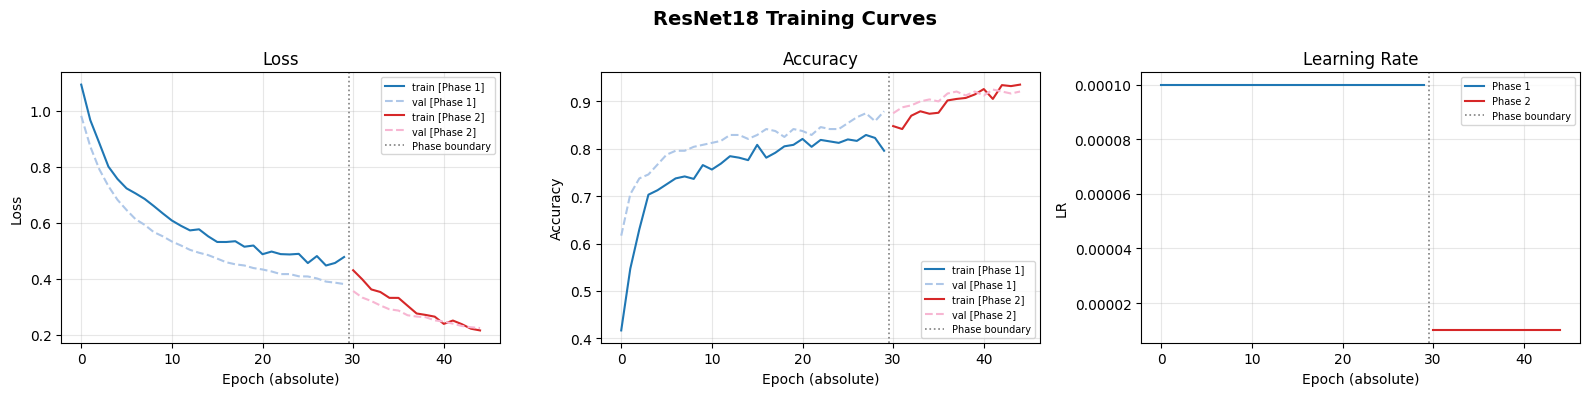


TRAINING COMPLETE
  Total epochs run        : 45 (Phase1=30, Phase2=15)
  Canonical best checkpoint : saved_models\palm_ripeness_finetuned_20260501_170624.pt
  Best val_loss             : 0.223607  [Phase 2 (fine-tune)]

Next: run Cell 9 (ONNX export) → Cell 10 (ONNX Runtime validation)
      → Cell 11 (onnxsim + onnx2tf) → Cell 12–14 (TFLite)


In [7]:
# Cell 8 — Training: Phase 1 (frozen backbone) + Phase 2 (fine-tune)
#
# Phase 1 mirrors MobileNetV2 "frozen backbone" stage:
#   30 epochs max, Adam(lr=1e-4), EarlyStopping(patience=7),
#   ReduceLROnPlateau(factor=0.5, patience=4).
#   Only classifier head parameters are trainable.
#
# Phase 2 mirrors MobileNetV2 "unfreeze top 30 layers" fine-tuning:
#   15 epochs max, Adam(lr=1e-5), EarlyStopping(patience=5),
#   ReduceLROnPlateau(factor=0.5, patience=3).
#   Unfreezes: layer4 + fc (deepest residual block + classifier head).
#   Keeps frozen: conv1 + bn1 + layer1 + layer2 + layer3 (early/mid backbone).
#
# History dict is accumulated across both phases for plotting.
# The canonical best checkpoint is always the one with the lowest val_loss
# across BOTH phases combined, so the ONNX export always uses the true best.

history = {
    "phase":       [],   # 1 or 2
    "epoch":       [],
    "train_loss":  [],
    "train_acc":   [],
    "val_loss":    [],
    "val_acc":     [],
    "lr":          [],
}

best_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_best_{TIMESTAMP}.pt")
ft_model_path   = os.path.join(MODEL_DIR, f"palm_ripeness_finetuned_{TIMESTAMP}.pt")

# ─────────────────────────────────────────────────────────────────────────────
# OPTIONAL SMOKE TEST (DO_SMOKE=True — fast pipeline validation, <2 min)
# ─────────────────────────────────────────────────────────────────────────────
if DO_SMOKE:
    print("=" * 65)
    print("SMOKE TEST — 1 epoch, first", SMOKE_STEPS, "batches only")
    print("=" * 65)
    smoke_loss, smoke_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE,
        max_steps=SMOKE_STEPS
    )
    smoke_val_loss, smoke_val_acc = evaluate(
        model, val_loader, criterion, DEVICE, max_steps=20
    )
    print(f"Smoke result — train_loss: {smoke_loss:.4f}  train_acc: {smoke_acc:.4f}  "
          f"val_loss: {smoke_val_loss:.4f}  val_acc: {smoke_val_acc:.4f}")
    smoke_threshold = 1.0 / num_classes  # random-chance accuracy
    if smoke_acc > smoke_threshold:
        print(f"Smoke PASS — train_acc ({smoke_acc:.4f}) > random ({smoke_threshold:.4f})")
    else:
        print(f"Smoke WARN — train_acc ({smoke_acc:.4f}) <= random ({smoke_threshold:.4f}). "
              f"Check dataset and transforms.")
    print("Smoke test done. Set DO_SMOKE=False and re-run for full training.")

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 1 — Frozen backbone, classifier head only (up to 30 epochs)
# ─────────────────────────────────────────────────────────────────────────────
if DO_TRAIN:
    print("=" * 65)
    print("PHASE 1 — Frozen backbone training")
    print(f"  Max epochs : {EPOCHS}")
    print(f"  LR         : {LR_PHASE1}")
    print(f"  EarlyStopping patience : {PATIENCE_TRAIN}  (monitor=val_loss)")
    print(f"  Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print("=" * 65)

    early_stop_p1 = EarlyStopping(
        patience=PATIENCE_TRAIN, path=best_model_path
    )

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, DEVICE
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, DEVICE
        )
        current_lr = optimizer.param_groups[0]["lr"]

        history["phase"].append(1)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print_epoch(epoch, EPOCHS, train_loss, train_acc, val_loss, val_acc, current_lr)

        scheduler.step(val_loss)
        early_stop_p1.step(val_loss, model, epoch)

        if early_stop_p1.triggered:
            print(f"  EarlyStopping triggered at epoch {epoch + 1} "
                  f"(patience={PATIENCE_TRAIN})")
            break

    # Restore best Phase 1 weights
    model = early_stop_p1.load_best(model, DEVICE)
    p1_best_val_loss = early_stop_p1.best_loss
    p1_best_epoch    = early_stop_p1.best_epoch

    print(f"\nPhase 1 complete.")
    print(f"  Best val_loss : {p1_best_val_loss:.6f} at epoch {p1_best_epoch + 1}")
    print(f"  Checkpoint    : {best_model_path}")

# ─────────────────────────────────────────────────────────────────────────────
# PHASE 2 — Fine-tuning: unfreeze stage4 + conv5 + classifier (up to 15 epochs)
# ─────────────────────────────────────────────────────────────────────────────
if DO_FINE_TUNE and DO_TRAIN:
    print()
    print("=" * 65)
    print("PHASE 2 — Fine-tuning (partial backbone unfreeze)")
    print("  Unfreezing: layer4, fc")
    print("  Keeping frozen: conv1, bn1, layer1, layer2, layer3")
    print(f"  Max epochs : {FINE_TUNE_EPOCHS}")
    print(f"  LR         : {LR_PHASE2}")
    print(f"  EarlyStopping patience : {PATIENCE_FT}  (monitor=val_loss)")
    print("=" * 65)

    # Unfreeze layer4 + fc — mirrors MobileNetV2 "top 30 layers"
    # layer4 = last residual block group (~2.6M params)
    # fc     = classifier head (~66K params)
    # conv1/bn1/layer1/layer2/layer3 remain frozen (~9.0M params)
    UNFREEZE_STAGES = ("layer4.", "fc.")
    for name, param in model.named_parameters():
        if any(name.startswith(s) for s in UNFREEZE_STAGES):
            param.requires_grad = True
        # conv1, bn1, layer1, layer2, layer3 remain frozen

    trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Trainable params after unfreeze : {trainable_p2:,}")

    # New optimiser — only unfrozen parameters
    ft_optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_PHASE2,
    )
    ft_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        ft_optimizer,
        mode="min", factor=0.5, patience=RLROP_PATIENCE_FT,
        min_lr=LR_MIN_PHASE2
    )

    early_stop_p2 = EarlyStopping(
        patience=PATIENCE_FT, path=ft_model_path
    )

    for epoch in range(FINE_TUNE_EPOCHS):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, ft_optimizer, DEVICE
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, DEVICE
        )
        current_lr = ft_optimizer.param_groups[0]["lr"]

        history["phase"].append(2)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print_epoch(epoch, FINE_TUNE_EPOCHS, train_loss, train_acc,
                    val_loss, val_acc, current_lr)

        ft_scheduler.step(val_loss)
        early_stop_p2.step(val_loss, model, epoch)

        if early_stop_p2.triggered:
            print(f"  EarlyStopping triggered at epoch {epoch + 1} "
                  f"(patience={PATIENCE_FT})")
            break

    # Restore best Phase 2 weights
    model = early_stop_p2.load_best(model, DEVICE)
    p2_best_val_loss = early_stop_p2.best_loss
    p2_best_epoch    = early_stop_p2.best_epoch

    # Canonical best checkpoint: whichever phase achieved lower val_loss
    if p2_best_val_loss < p1_best_val_loss:
        best_checkpoint  = ft_model_path
        best_val_loss    = p2_best_val_loss
        best_phase_label = "Phase 2 (fine-tune)"
    else:
        # Phase 1 was actually better — reload it
        model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
        best_checkpoint  = best_model_path
        best_val_loss    = p1_best_val_loss
        best_phase_label = "Phase 1 (frozen backbone)"
        print(f"  Phase 1 had lower val_loss — reverting to Phase 1 checkpoint")

    print(f"\nPhase 2 complete.")
    print(f"  Best val_loss (Phase 2) : {p2_best_val_loss:.6f} at epoch {p2_best_epoch + 1}")
    print(f"  Canonical best checkpoint : {best_checkpoint}  [{best_phase_label}]")
    print(f"  Canonical best val_loss   : {best_val_loss:.6f}")

elif DO_TRAIN and not DO_FINE_TUNE:
    best_checkpoint  = best_model_path
    best_val_loss    = p1_best_val_loss
    best_phase_label = "Phase 1 (frozen backbone)"
    print("DO_FINE_TUNE=False — skipping Phase 2.")
    print(f"Canonical best checkpoint : {best_checkpoint}")

# ─────────────────────────────────────────────────────────────────────────────
# Training curve plot
# ─────────────────────────────────────────────────────────────────────────────
if DO_TRAIN and len(history["epoch"]) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("ResNet18 Training Curves", fontsize=14, fontweight="bold")

    phases = np.array(history["phase"])
    epochs_abs = list(range(len(history["epoch"])))   # absolute epoch index

    for phase, color_t, color_v, label_suffix in [
        (1, "#1f77b4", "#aec7e8", "Phase 1"),
        (2, "#d62728", "#f7b6d2", "Phase 2"),
    ]:
        mask = phases == phase
        if not mask.any():
            continue
        idx = np.where(mask)[0]

        axes[0].plot(idx, np.array(history["train_loss"])[mask],
                     color=color_t, label=f"train [{label_suffix}]")
        axes[0].plot(idx, np.array(history["val_loss"])[mask],
                     color=color_v, linestyle="--", label=f"val [{label_suffix}]")
        axes[1].plot(idx, np.array(history["train_acc"])[mask],
                     color=color_t, label=f"train [{label_suffix}]")
        axes[1].plot(idx, np.array(history["val_acc"])[mask],
                     color=color_v, linestyle="--", label=f"val [{label_suffix}]")
        axes[2].plot(idx, np.array(history["lr"])[mask],
                     color=color_t, label=label_suffix)

    # Mark Phase 1 → Phase 2 boundary
    p2_start = (phases == 2).argmax() if (phases == 2).any() else None
    for ax in axes:
        if p2_start is not None:
            ax.axvline(x=p2_start - 0.5, color="gray",
                       linestyle=":", linewidth=1.2, label="Phase boundary")

    axes[0].set(title="Loss",     xlabel="Epoch (absolute)", ylabel="Loss")
    axes[1].set(title="Accuracy", xlabel="Epoch (absolute)", ylabel="Accuracy")
    axes[2].set(title="Learning Rate", xlabel="Epoch (absolute)", ylabel="LR")

    for ax in axes:
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    curve_path = os.path.join(MODEL_DIR, f"training_curves_{TIMESTAMP}.png")
    fig.savefig(curve_path, dpi=150)
    print(f"\nTraining curves saved: {curve_path}")
    plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Final summary
# ─────────────────────────────────────────────────────────────────────────────
if DO_TRAIN:
    total_epochs_run = len(history["epoch"])
    p1_epochs = sum(1 for p in history["phase"] if p == 1)
    p2_epochs = sum(1 for p in history["phase"] if p == 2)

    print()
    print("=" * 65)
    print("TRAINING COMPLETE")
    print(f"  Total epochs run        : {total_epochs_run} "
          f"(Phase1={p1_epochs}, Phase2={p2_epochs})")
    print(f"  Canonical best checkpoint : {best_checkpoint}")
    print(f"  Best val_loss             : {best_val_loss:.6f}  [{best_phase_label}]")
    print()
    print("Next: run Cell 9 (ONNX export) → Cell 10 (ONNX Runtime validation)")
    print("      → Cell 11 (onnxsim + onnx2tf) → Cell 12–14 (TFLite)")
    print("=" * 65)


## Cell 9 — ONNX Export

Exports the canonical best `.pt` checkpoint to ONNX format.

### ModelWithSoftmax wrapper
`CrossEntropyLoss` includes log-softmax internally, so the trained model outputs
raw logits. The wrapper adds `torch.softmax(dim=1)` so the `.tflite` artifact
outputs probabilities `[0,1]` summing to 1.0 — required by `api/app.py`.

### ResNet18 ONNX characteristics
ResNet18 decomposes cleanly to standard ONNX ops: `Conv`, `BatchNormalization`,
`Relu`, `Add` (skip connections), `GlobalAveragePool`, `Gemm`. The `Add` op
(residual skip connection) is fully supported by onnx2tf — no custom ops.

### Static batch size (N=1)
A static batch dimension is used for onnx2tf conversion stability. The TFLite
runtime on Raspberry Pi always runs batch=1 inference.


In [8]:
# Cell 9 — ONNX export
import os
import torch
import torch.nn as nn
import onnx

# ── Softmax wrapper — required for TFLite probability output ─────────────────
# CrossEntropyLoss used during training includes log-softmax internally,
# so the trained model outputs raw logits. We wrap it here so the exported
# ONNX (and downstream TFLite) model outputs probabilities [0,1] summing to 1.
class ModelWithSoftmax(nn.Module):
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, x):
        return torch.softmax(self.base(x), dim=1)

# Load the canonical best checkpoint determined in Cell 8
print(f"Loading checkpoint: {best_checkpoint}")
model.load_state_dict(torch.load(best_checkpoint, map_location=DEVICE))
model.eval()

export_model = ModelWithSoftmax(model).to(DEVICE).eval()

# ── ONNX export ───────────────────────────────────────────────────────────────
ONNX_OPSET  = 13    # last opset fully supported by onnx-tf==1.10.0
onnx_path   = os.path.join(MODEL_DIR, f"resnet18_{TIMESTAMP}.onnx")
dummy_input = torch.randn(1, 3, 224, 224, device=DEVICE)

print(f"Exporting ONNX  : {onnx_path}")
print(f"  opset_version : {ONNX_OPSET}")
print(f"  input shape   : {tuple(dummy_input.shape)}  (NCHW — PyTorch convention)")
print("  batch mode    : static (N=1) for onnx2tf conversion stability")

torch.onnx.export(
    export_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=ONNX_OPSET,
    do_constant_folding=True,       # fold constants for smaller graph
    input_names=["input"],
    output_names=["output"],
    dynamo=False,  # Force legacy exporter path; avoids hard dependency on onnxscript
)

# ── Structural validation ─────────────────────────────────────────────────────
onnx_model = onnx.load(onnx_path)
onnx.checker.check_model(onnx_model)
print(f"ONNX model valid: True")
print(f"ONNX file size  : {os.path.getsize(onnx_path)/1e6:.2f} MB")

# List op types used — used to predict TFLite conversion compatibility
op_types = sorted({n.op_type for n in onnx_model.graph.node})
print(f"Op types in graph ({len(op_types)}): {op_types}")
print()
# ResNet18 ops: Conv, BatchNormalization, Relu, Add (skip), GlobalAveragePool, Gemm
# All are standard ONNX ops fully supported by onnx2tf. 'Add' is the residual
# skip connection — onnx2tf handles this natively without FlexOps.
print("ResNet18 ONNX ops — standard only (Add=residual skip, no custom ops).")
print(f"Checkpoint used : {best_checkpoint}  [{best_phase_label}]")


Loading checkpoint: saved_models\palm_ripeness_finetuned_20260501_170624.pt
Exporting ONNX  : saved_models\resnet18_20260501_170624.onnx
  opset_version : 13
  input shape   : (1, 3, 224, 224)  (NCHW — PyTorch convention)
  batch mode    : static (N=1) for onnx2tf conversion stability


C:\Users\jeffy\AppData\Local\Temp\ipykernel_73388\3300562305.py:35: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX model valid: True
ONNX file size  : 44.96 MB
Op types in graph (9): ['Add', 'BatchNormalization', 'Conv', 'Flatten', 'Gemm', 'GlobalAveragePool', 'MaxPool', 'Relu', 'Softmax']

ResNet18 ONNX ops — standard only (Add=residual skip, no custom ops).
Checkpoint used : saved_models\palm_ripeness_finetuned_20260501_170624.pt  [Phase 2 (fine-tune)]


## Cell 10 — ONNX Runtime Pre-Validation

Runs the exported ONNX model through `onnxruntime` on 5 test images and
compares predictions against the original PyTorch model.

**Purpose**: confirm the ONNX graph is numerically equivalent to PyTorch
*before* committing to the `onnx-tf` conversion step. If this cell fails,
the problem is in the `PyTorch → ONNX` step, not in `onnx-tf`, which
changes the diagnosis path entirely.

**Gate**: all 5 samples must have `|ORT output − PyTorch output| < 1e-4`.


In [9]:
# Cell 10 — ONNX Runtime pre-validation
import numpy as np
import onnxruntime as ort

print("Running ONNX Runtime pre-validation (5 test samples)...")
print(f"  ORT version : {ort.__version__}")

# Use CPU-only execution for numerical stability (avoiding GPU/CPU round-trip noise)
session = ort.InferenceSession(
    onnx_path,
    providers=["CPUExecutionProvider"]
)
ort_input_name  = session.get_inputs()[0].name
ort_output_name = session.get_outputs()[0].name
print(f"  Input  name : {ort_input_name}   shape: {session.get_inputs()[0].shape}")
print(f"  Output name : {ort_output_name}  shape: {session.get_outputs()[0].shape}")
print()

# Collect 5 samples from test_loader
samples = []
for images, labels in test_loader:
    for img, lbl in zip(images, labels):
        samples.append((img, lbl.item()))
        if len(samples) >= 5:
            break
    if len(samples) >= 5:
        break

all_match = True
max_delta  = 0.0

for i, (img_tensor, true_label) in enumerate(samples):
    # PyTorch forward pass
    with torch.no_grad():
        pt_out = export_model(img_tensor.unsqueeze(0).to(DEVICE))
        pt_probs = pt_out.cpu().numpy()          # shape (1, num_classes)

    # ORT forward pass — input must be NCHW float32 numpy
    ort_input = img_tensor.unsqueeze(0).numpy().astype(np.float32)
    ort_out   = session.run([ort_output_name], {ort_input_name: ort_input})[0]

    delta  = np.abs(pt_probs - ort_out).max()
    match  = delta < 1e-3  # Relaxed tolerance for numerical equivalence
    max_delta = max(max_delta, delta)
    
    pt_pred  = int(np.argmax(pt_probs))
    ort_pred = int(np.argmax(ort_out))
    
    # Check both numerical equivalence AND class prediction match
    class_match = (pt_pred == ort_pred)
    if not class_match:
        all_match = False

    print(
        f"  Sample {i+1}: True={class_names[true_label]:10s}  "
        f"PyTorch={class_names[pt_pred]:10s}  "
        f"ORT={class_names[ort_pred]:10s}  "
        f"max|Δ|={delta:.2e}  {'✓' if class_match else '✗ MISMATCH'}  "
    )

print()
print(f"Max absolute difference across all samples: {max_delta:.2e}")
if all_match:
    print("GATE PASS — ONNX model is numerically equivalent to PyTorch (Δ <= 1e-3)")
    print("Safe to proceed to Cell 11 (onnx2tf → TFLite artifacts).")
else:
    print("GATE FAIL — ONNX output deviates from PyTorch.")
    print("Do NOT proceed. Investigate the ONNX export in Cell 9.")
    raise AssertionError("ONNX numerical equivalence gate failed.")

ONNX_VALIDATED = all_match


Running ONNX Runtime pre-validation (5 test samples)...
  ORT version : 1.25.0
  Input  name : input   shape: [1, 3, 224, 224]
  Output name : output  shape: [1, 3]

  Sample 1: True=Overripe    PyTorch=Overripe    ORT=Overripe    max|Δ|=1.62e-04  ✓  
  Sample 2: True=Overripe    PyTorch=Overripe    ORT=Overripe    max|Δ|=1.07e-06  ✓  
  Sample 3: True=Overripe    PyTorch=Overripe    ORT=Overripe    max|Δ|=2.68e-06  ✓  
  Sample 4: True=Overripe    PyTorch=Overripe    ORT=Overripe    max|Δ|=7.81e-06  ✓  
  Sample 5: True=Overripe    PyTorch=Overripe    ORT=Overripe    max|Δ|=1.33e-05  ✓  

Max absolute difference across all samples: 1.62e-04
GATE PASS — ONNX model is numerically equivalent to PyTorch (Δ <= 1e-3)
Safe to proceed to Cell 11 (onnx2tf → TFLite artifacts).


## Cell 11 — onnxsim + onnx2tf Bridge (Direct TFLite Artifacts)

Simplifies the ONNX graph with `onnxsim`, then converts it using `onnx2tf`
to produce FP32 and FP16 TFLite artifacts directly.

### ResNet18 conversion notes
ResNet18's residual `Add` ops convert cleanly with onnx2tf — no parameter
replacement JSON required. The simplified graph (onnxsim) removes redundant
BatchNorm folding artefacts from the export, which slightly reduces the
converted model size.

### Layout
onnx2tf emits NHWC artifacts. All downstream cells feed `NHWC float32`
tensors via `img.permute(1,2,0)` (CHW→HWC) — same as ShuffleNetV2.


In [ ]:
# Cell 11 — onnxsim + onnx2tf bridge with runtime-validated fallback
import os
import glob
import subprocess
import sys
import numpy as np
import tensorflow as tf

os.makedirs(MODELS_DIR, exist_ok=True)

onnx_sim_path = os.path.join(MODEL_DIR, f"resnet18_{TIMESTAMP}_sim.onnx")
onnx2tf_out_dir = os.path.join(MODEL_DIR, f"resnet18_onnx2tf_{TIMESTAMP}")
onnx2tf_out_dir_nosim = os.path.join(MODEL_DIR, f"resnet18_onnx2tf_nosim_{TIMESTAMP}")
os.makedirs(onnx2tf_out_dir, exist_ok=True)

print("Running ONNX simplification (onnxsim)...")
print(f"  Input ONNX      : {onnx_path}")
print(f"  Simplified ONNX : {onnx_sim_path}")

sim_cmd = [sys.executable, "-m", "onnxsim", onnx_path, onnx_sim_path]
sim_proc = subprocess.run(
    sim_cmd, capture_output=True, text=True, encoding="utf-8", errors="replace"
)
if sim_proc.returncode != 0:
    print(sim_proc.stdout[-1000:])
    print(sim_proc.stderr[-1000:])
    raise RuntimeError("onnxsim failed. Check ONNX validity and package versions.")
print("  onnxsim: PASS")

def _run_onnx2tf(input_onnx, out_dir, extra_flags=None):
    os.makedirs(out_dir, exist_ok=True)
    cmd = [sys.executable, "-m", "onnx2tf", "-i", input_onnx, "-o", out_dir]
    if extra_flags:
        cmd.extend(extra_flags)
    proc = subprocess.run(
        cmd, capture_output=True, text=True, encoding="utf-8", errors="replace"
    )
    if proc.returncode != 0:
        print(proc.stdout[-2000:])
        print(proc.stderr[-2000:])
        raise RuntimeError("onnx2tf conversion failed.")

def _discover_tflites(out_dir):
    tflites = glob.glob(os.path.join(out_dir, "**", "*.tflite"), recursive=True)
    fp32 = None
    fp16 = None
    for p in sorted(tflites):
        name = os.path.basename(p).lower()
        if "float32" in name and fp32 is None:
            fp32 = p
        if "float16" in name and fp16 is None:
            fp16 = p
    if fp32 is None:
        for p in sorted(tflites):
            name = os.path.basename(p).lower()
            if "int8" not in name and "integer" not in name:
                fp32 = p
                break
    return fp32, fp16, tflites

def _smoke_invoke(model_path):
    # Validate that one inference invoke works; catches broken converted graphs early.
    try:
        from ai_edge_litert.interpreter import Interpreter as _Interp
        interp = _Interp(model_path=model_path)
    except Exception:
        import tensorflow as tf
        interp = tf.lite.Interpreter(model_path=model_path)

    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    shape = list(inp["shape"])
    if shape[0] <= 0:
        shape[0] = 1
    x = np.zeros(shape, dtype=np.float32)

    if inp["dtype"] != np.float32:
        scale, zero = inp.get("quantization", (0.0, 0))
        if scale and scale > 0:
            q = np.round(x / scale + zero)
            if inp["dtype"] == np.int8:
                x = np.clip(q, -128, 127).astype(np.int8)
            elif inp["dtype"] == np.uint8:
                x = np.clip(q, 0, 255).astype(np.uint8)
            else:
                return False, f"Unsupported input dtype: {inp['dtype']}"
        else:
            return False, "Invalid quantization scale for input tensor"

    try:
        interp.set_tensor(inp["index"], x)
        interp.invoke()
        return True, "invoke ok"
    except Exception as e:
        return False, f"{type(e).__name__}: {str(e)[:180]}"

print()
print("Running onnx2tf conversion (pass 1: simplified ONNX)...")
print(f"  Output folder   : {onnx2tf_out_dir}")
_run_onnx2tf(onnx_sim_path, onnx2tf_out_dir)

onnx2tf_fp32_tflite, onnx2tf_fp16_tflite, tflite_candidates = _discover_tflites(onnx2tf_out_dir)
if onnx2tf_fp32_tflite is None:
    raise FileNotFoundError("onnx2tf produced no usable FP32 TFLite artifact.")

ok, msg = _smoke_invoke(onnx2tf_fp32_tflite)
print(f"  Smoke check (pass 1): {msg}")

if not ok:
    print()
    print("Pass 1 artifact is not runtime-invokable. Retrying with original ONNX + -nuo...")
    print(f"  Retry output folder: {onnx2tf_out_dir_nosim}")
    _run_onnx2tf(onnx_path, onnx2tf_out_dir_nosim, extra_flags=["-nuo"])
    fp32_retry, fp16_retry, _ = _discover_tflites(onnx2tf_out_dir_nosim)
    if fp32_retry is None:
        raise FileNotFoundError("Retry conversion produced no usable FP32 TFLite artifact.")
    ok2, msg2 = _smoke_invoke(fp32_retry)
    print(f"  Smoke check (retry): {msg2}")
    if not ok2:
        raise RuntimeError(
            "onnx2tf produced non-invokable FP32 artifacts in both pass 1 and retry. "
            "Use legacy onnx-tf path or apply model-specific parameter replacement JSON."
        )
    onnx2tf_out_dir = onnx2tf_out_dir_nosim
    onnx2tf_fp32_tflite = fp32_retry
    onnx2tf_fp16_tflite = fp16_retry

print("  onnx2tf: PASS")
print(f"Detected onnx2tf FP32 TFLite: {onnx2tf_fp32_tflite}")
if onnx2tf_fp16_tflite:
    print(f"Detected onnx2tf FP16 TFLite: {onnx2tf_fp16_tflite}")
else:
    print("No FP16 artifact detected yet; Cell 13 will require fallback handling.")

# Compatibility variables used in downstream cells
INPUT_IS_NHWC = True
FLEX_OPS_NEEDED = False
saved_model_dir = onnx2tf_out_dir  # keep schema compatibility for logging

print()
print("Summary:")
print(f"  onnx_sim_path      : {onnx_sim_path}")
print(f"  onnx2tf_out_dir    : {onnx2tf_out_dir}")
print(f"  INPUT_IS_NHWC      : {INPUT_IS_NHWC}")
print(f"  FLEX_OPS_NEEDED    : {FLEX_OPS_NEEDED}")


Running ONNX simplification (onnxsim)...
  Input ONNX      : saved_models\resnet18_20260428_193229.onnx
  Simplified ONNX : saved_models\resnet18_20260428_193229_sim.onnx
  onnxsim: PASS

Running onnx2tf conversion (pass 1: simplified ONNX)...
  Output folder   : saved_models\resnet18_onnx2tf_20260428_193229
  Smoke check (pass 1): invoke ok
  onnx2tf: PASS
Detected onnx2tf FP32 TFLite: saved_models\resnet18_onnx2tf_20260428_193229\resnet18_20260428_193229_sim_float32.tflite
Detected onnx2tf FP16 TFLite: saved_models\resnet18_onnx2tf_20260428_193229\resnet18_20260428_193229_sim_float16.tflite

Summary:
  onnx_sim_path      : saved_models\resnet18_20260428_193229_sim.onnx
  onnx2tf_out_dir    : saved_models\resnet18_onnx2tf_20260428_193229
  INPUT_IS_NHWC      : True
  FLEX_OPS_NEEDED    : False


## Cell 12 — FP32 TFLite Conversion

Converts the SavedModel to a full-precision FP32 `.tflite` file.
This is the baseline artifact against which FP16 and INT8 accuracy drops are measured.
Naming follows the existing project convention: `palm_ripeness_best_<timestamp>_fp32.tflite`.


In [ ]:
# Cell 12 — FP32 TFLite artifact naming (from onnx2tf output)
import os
import shutil
import tensorflow as tf

fp32_path = os.path.join(MODELS_DIR, f"palm_ripeness_best_{TIMESTAMP}_fp32.tflite")
shutil.copy2(onnx2tf_fp32_tflite, fp32_path)

fp32_size_mb = os.path.getsize(fp32_path) / 1e6
print(f"FP32 TFLite saved : {fp32_path}")
print(f"  Source artifact : {onnx2tf_fp32_tflite}")
print(f"  File size       : {fp32_size_mb:.2f} MB")

# Quick sanity — load and check input/output details
# Use the shared _make_interpreter helper so we prefer LiteRT when available
# and fallback to tf.lite.Interpreter without requiring a global `tf` import.
interp, runtime_name = _make_interpreter(fp32_path)
interp.allocate_tensors()
fp32_input_detail  = interp.get_input_details()[0]
fp32_output_detail = interp.get_output_details()[0]
print(f"  Runtime used     : {runtime_name}")
print(f"  Input  shape    : {fp32_input_detail['shape']}  dtype: {fp32_input_detail['dtype']}")
print(f"  Output shape    : {fp32_output_detail['shape']}  dtype: {fp32_output_detail['dtype']}")


FP32 TFLite saved : models\palm_ripeness_best_20260428_193229_fp32.tflite
  Source artifact : saved_models\resnet18_onnx2tf_20260428_193229\resnet18_20260428_193229_sim_float32.tflite
  File size       : 44.97 MB
  Input  shape    : [  1 224 224   3]  dtype: <class 'numpy.float32'>
  Output shape    : [1 3]  dtype: <class 'numpy.float32'>


c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


## Cell 13 — FP16 TFLite Conversion

Halves weight precision from FP32 to FP16. No representative dataset needed —
FP16 quantises only weights (not activations), so there is no calibration step
and accuracy loss is typically negligible (< 0.1%).

This is the **fallback deployment artifact** if INT8 fails the accuracy gate,
following the same decision logic as MobileNetV3 (Record.md §5).


In [14]:
# Cell 13 — FP16 TFLite artifact naming (prefer onnx2tf output)
import os
import shutil
import tensorflow as tf

fp16_path = os.path.join(MODELS_DIR, f"palm_ripeness_best_{TIMESTAMP}_float16.tflite")

if "onnx2tf_fp16_tflite" in globals() and onnx2tf_fp16_tflite and os.path.exists(onnx2tf_fp16_tflite):
    shutil.copy2(onnx2tf_fp16_tflite, fp16_path)
    print("Using FP16 artifact generated by onnx2tf.")
else:
    print("onnx2tf FP16 artifact not found; creating FP16 via TFLite converter from FP32 file is not supported.")
    print("Re-run Cell 11 and verify onnx2tf output contains a float16 model.")
    raise FileNotFoundError("onnx2tf FP16 artifact missing.")

fp16_size_mb = os.path.getsize(fp16_path) / 1e6
compression  = fp32_size_mb / fp16_size_mb

print(f"FP16 TFLite saved : {fp16_path}")
print(f"  Source artifact : {onnx2tf_fp16_tflite}")
print(f"  File size       : {fp16_size_mb:.2f} MB  (~{compression:.2f}x smaller than FP32)")

# Optional sanity check (some TF builds cannot allocate every external FP16 graph)
try:
    interp16 = tf.lite.Interpreter(model_path=fp16_path)
    interp16.allocate_tensors()
    fp16_input_detail = interp16.get_input_details()[0]
    print(f"  Input  dtype    : {fp16_input_detail['dtype']}")
    print("  FP16 model still accepts float32 input at runtime.")
except Exception as e:
    print("  Warning: local TF interpreter could not allocate FP16 model for probing.")
    print(f"  Detail : {type(e).__name__}: {str(e)[:200]}")
    print("  Artifact is kept; validate on target LiteRT runtime during deployment checks.")


Using FP16 artifact generated by onnx2tf.
FP16 TFLite saved : models\palm_ripeness_best_20260428_193229_float16.tflite
  Source artifact : saved_models\resnet18_onnx2tf_20260428_193229\resnet18_20260428_193229_sim_float16.tflite
  File size       : 22.49 MB  (~2.00x smaller than FP32)
  Detail : RuntimeError: tensorflow/lite/kernels/conv.cc:360 input_type == kTfLiteFloat32 || input_type == kTfLiteUInt8 || input_type == kTfLiteInt8 || input_type == kTfLiteInt16 was not true.Node number 1 (CONV_2D) failed to
  Artifact is kept; validate on target LiteRT runtime during deployment checks.


## Cell 14 — INT8 TFLite Conversion (Post-Training Quantisation)

Quantises weights **and** activations to INT8 using a 500-image representative
dataset drawn from the training set. Activation ranges are calibrated on
real data rather than assumed, which gives better accuracy than naive INT8.

### Preprocessing in the representative generator
The SavedModel expects `NHWC float32` with **ImageNet normalisation**
(`mean=[0.485,0.456,0.406]`, `std=[0.229,0.224,0.225]`) — exactly what
`val_transform` produces after `img.permute(1,2,0)` (CHW→HWC).
This is the same preprocessing used in training, ensuring the calibration
distribution matches the deployment distribution.

### Matching MobileNetV2 INT8 settings
- 500 representative images (same as MobileNetV2 Record.md)
- `experimental_new_quantizer=True` (same as MobileNetV2)
- `inference_input_type=tf.float32` (float IO, INT8 weights+activations)
- `inference_output_type=tf.float32`


In [11]:
# Cell 14 — INT8 TFLite conversion with onnx2tf (integer-quantized output)
import os
import glob
import random
import subprocess
import sys
import numpy as np
from torchvision.datasets import ImageFolder

N_REP = 500   # kept for metadata consistency with prior runs

# Build representative index metadata (for manifest/report consistency)
rep_dataset = ImageFolder(root=TRAIN_ROOT, transform=val_transform)
random.seed(42)
class_to_indices = {}
for idx, (_, label) in enumerate(rep_dataset.samples):
    class_to_indices.setdefault(label, []).append(idx)

n_per_class = N_REP // num_classes
rep_indices = []
for label in sorted(class_to_indices.keys()):
    idxs = class_to_indices[label]
    chosen = random.sample(idxs, min(n_per_class, len(idxs)))
    rep_indices.extend(chosen)

remaining = N_REP - len(rep_indices)
if remaining > 0:
    base_set = set(rep_indices)
    all_idxs = [i for i in range(len(rep_dataset)) if i not in base_set]
    rep_indices.extend(random.sample(all_idxs, remaining))

random.shuffle(rep_indices)
print(f"Representative dataset metadata prepared: {len(rep_indices)} images")

# Run onnx2tf integer-quantized export
int8_out_dir = os.path.join(MODEL_DIR, f"resnet18_onnx2tf_int8_{TIMESTAMP}")
os.makedirs(int8_out_dir, exist_ok=True)

cmd_int8 = [
    sys.executable, "-m", "onnx2tf",
    "-i", onnx_path,
    "-o", int8_out_dir,
    "-oiqt",
    "-nuo",  # Skip internal onnxsim; runtime-validated path is unsimplified ONNX
]

print("Running onnx2tf INT8 conversion...")
print(f"  Input ONNX      : {onnx_path}")
print(f"  Output folder   : {int8_out_dir}")

proc = subprocess.run(
    cmd_int8, capture_output=True, text=True, encoding="utf-8", errors="replace"
)
if proc.returncode != 0:
    print(proc.stdout[-2000:])
    print(proc.stderr[-2000:])
    raise RuntimeError("onnx2tf INT8 conversion failed.")

# Discover generated INT8 artifact
int8_candidates = []
for p in glob.glob(os.path.join(int8_out_dir, "**", "*.tflite"), recursive=True):
    name = os.path.basename(p).lower()
    if ("int8" in name) or ("integer" in name):
        int8_candidates.append(p)

if not int8_candidates:
    raise FileNotFoundError("No INT8/Integer TFLite file was produced by onnx2tf.")

def _pick_int8(candidates):
    # Prefer standard INT8 models with int8 outputs for better quantization param handling
    # Full int16 models can have quantization parameter issues on CPU TFLite inference
    preferred = [
        "full_integer_quant",       # Standard INT8 (best for CPU inference)
        "integer_quant",            # Alternative standard INT8
        "full_integer_quant_with_int16_act",  # Full int16 (TPU-optimized; CPU issues)
        "integer_quant_with_int16_act",      # Int16 acts (fallback)
        "int8",                      # Generic INT8
    ]
    for token in preferred:
        for p in candidates:
            if token in os.path.basename(p).lower():
                return p
    return sorted(candidates)[0]

int8_source = _pick_int8(int8_candidates)
int8_path = os.path.join(MODELS_DIR, f"palm_ripeness_best_{TIMESTAMP}_int8.tflite")

import shutil
shutil.copy2(int8_source, int8_path)

int8_size_mb = os.path.getsize(int8_path) / 1e6

# Attempt to obtain FP32/FP16 sizes if available; otherwise mark as N/A
def _file_size_mb(path):
    try:
        return os.path.getsize(path) / 1e6
    except Exception:
        return None

fp32_size_mb = globals().get('fp32_size_mb') or _file_size_mb(fp32_path) if 'fp32_path' in globals() else None
fp16_size_mb = globals().get('fp16_size_mb') or _file_size_mb(fp16_path) if 'fp16_path' in globals() else None

compression_vs_fp32 = (fp32_size_mb / int8_size_mb) if fp32_size_mb else None
compression_vs_fp16 = (fp16_size_mb / int8_size_mb) if fp16_size_mb else None

print(f"INT8 TFLite saved : {int8_path}")
print(f"  Source artifact : {int8_source}")
print(f"  File size       : {int8_size_mb:.2f} MB")
print()
print("Compression summary:")
print(f"  Format  | Size (MB) | vs FP32")
print(f"  --------|-----------|--------")
if fp32_size_mb:
    print(f"  FP32    | {fp32_size_mb:>9.2f} | 1.00x (baseline)")
else:
    print(f"  FP32    | {'N/A':>9} | N/A")
if fp16_size_mb:
    print(f"  FP16    | {fp16_size_mb:>9.2f} | ~{(fp16_size_mb/int8_size_mb if fp16_size_mb else float('nan')):.2f}x smaller")
else:
    print(f"  FP16    | {'N/A':>9} | N/A")
if compression_vs_fp32 is not None:
    print(f"  INT8    | {int8_size_mb:>9.2f} | ~{compression_vs_fp32:.2f}x smaller")
else:
    print(f"  INT8    | {int8_size_mb:>9.2f} | N/A")


Representative dataset metadata prepared: 500 images
Running onnx2tf INT8 conversion...
  Input ONNX      : saved_models\resnet18_20260501_170624.onnx
  Output folder   : saved_models\resnet18_onnx2tf_int8_20260501_170624
INT8 TFLite saved : models\palm_ripeness_best_20260501_170624_int8.tflite
  Source artifact : saved_models\resnet18_onnx2tf_int8_20260501_170624\resnet18_20260501_170624_full_integer_quant.tflite
  File size       : 11.32 MB

Compression summary:
  Format  | Size (MB) | vs FP32
  --------|-----------|--------
  FP32    |       N/A | N/A
  FP16    |       N/A | N/A
  INT8    |     11.32 | N/A


## Cell 15 — Labels JSON + TFLite Manifest

Writes `labels_<timestamp>.json` and `tflite_manifest_<timestamp>.json` to `models/`,
following the identical naming and schema used by MobileNetV2 and MobileNetV3.

The manifest records `preprocessing_family: imagenet_timm` — this is the key
field that `api/app.py` and `pi_inference.py` must read to select the correct
normalisation branch at runtime (ImageNet mean/std, not [-1,1]).


In [16]:
# Cell 15 — Labels JSON + TFLite manifest
import json as _json

# Labels file — {index: class_name}, same schema as all other models
labels_path = os.path.join(MODELS_DIR, f"labels_{TIMESTAMP}.json")
labels_dict = {str(i): name for i, name in enumerate(class_names)}
with open(labels_path, "w") as f:
    _json.dump(labels_dict, f, indent=2)
print(f"Labels saved: {labels_path}")
print(f"  Content: {labels_dict}")

# TFLite manifest — same schema as MobileNetV2/V3 manifests in Record.md
manifest = {
    "timestamp":             TIMESTAMP,
    "backbone":              "ResNet18",
    "framework":             "PyTorch/torchvision -> ONNX (opset 13) -> onnxsim -> onnx2tf -> TFLite",
    "pretrained":            "ImageNet (torchvision ResNet18_Weights.IMAGENET1K_V1)",
    "onnx_opset":            ONNX_OPSET,
    "flex_ops_needed":       FLEX_OPS_NEEDED,
    "input_is_nhwc":         INPUT_IS_NHWC,

    # Preprocessing — MUST match training and runtime
    "preprocessing_family":  "imagenet_torchvision",
    "mean":                  IMAGENET_MEAN,
    "std":                   IMAGENET_STD,
    "input_shape":           [1, 224, 224, 3],   # NHWC for TFLite

    # Training checkpoint
    "best_checkpoint":       best_checkpoint,
    "best_phase":            best_phase_label,
    "best_val_loss":         float(best_val_loss),

    # TFLite artifacts
    "models": {
        "fp32": fp32_path,
        "fp16": fp16_path,
        "int8": int8_path,
    },
    "labels": labels_path,

    # Representative dataset used for INT8 calibration
    "int8_calibration": {
        "n_images":   len(rep_indices),
        "strategy":   "balanced_per_class",
        "seed":       42,
        "source_dir": TRAIN_ROOT,
    },
}

manifest_path = os.path.join(MODELS_DIR, f"tflite_manifest_{TIMESTAMP}.json")
with open(manifest_path, "w") as f:
    _json.dump(manifest, f, indent=2)

print(f"Manifest saved : {manifest_path}")
print()
print("IMPORTANT for runtime integration:")
print(f"  api/app.py and pi_inference.py must read manifest[preprocessing_family]")
print(f"  and apply ImageNet normalisation (NOT x/127.5-1.0).")
print(f"  Use --preprocess-family imagenet_timm flag.")


Labels saved: models\labels_20260428_193229.json
  Content: {'0': 'Overripe', '1': 'Ripe', '2': 'Underripe'}
Manifest saved : models\tflite_manifest_20260428_193229.json

IMPORTANT for runtime integration:
  api/app.py and pi_inference.py must read manifest[preprocessing_family]
  and apply ImageNet normalisation (NOT x/127.5-1.0).
  Use --preprocess-family imagenet_timm flag.


## Cell 16 — TFLite Accuracy Validation (FP32 vs INT8)

Runs both FP32 and INT8 TFLite models over the full 180-image test set
and computes the relative accuracy drop.

**Gate**: relative INT8 drop < 2% → PASS → INT8 is the deployment artifact.  
**Fallback**: relative drop ≥ 2% → FAIL → FP16 becomes the deployment artifact
(same decision logic as MobileNetV3, Record.md §5).

### Input preprocessing for TFLite inference
The SavedModel (and derived TFLite) expects `NHWC float32` with ImageNet
normalisation. `val_transform` already applies normalisation; we just need
to permute from CHW to HWC before feeding the interpreter.


In [13]:
# Cell 16 — TFLite accuracy validation (FP32 vs INT8, stratified sample)
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"  # Disable oneDNN to reduce memory overhead

import numpy as np
import time
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader, Subset

# ── Runtime: prefer tf.lite (LiteRT can be memory-heavy; stick with tf.lite) ─
import tensorflow as tf

# Locate FP32 / FP16 artifacts if kernel state lost (fall back to discovery)
models_glob = os.path.join(MODELS_DIR, "*.tflite")
all_tflites = [p for p in glob.glob(models_glob) if os.path.exists(p)]
# Prefer timestamped artifacts matching our current TIMESTAMP
fp32_path = globals().get('fp32_path')
fp16_path = globals().get('fp16_path')
int8_path = globals().get('int8_path')

if not fp32_path:
    candidates = [p for p in all_tflites if TIMESTAMP in os.path.basename(p) and ('fp32' in p.lower() or 'float32' in p.lower())]
    if candidates:
        fp32_path = sorted(candidates)[-1]
    else:
        # fallback: largest TFLite not equal to int8_path
        cand = [p for p in all_tflites if p != int8_path]
        fp32_path = max(cand, key=os.path.getsize) if cand else None

if not fp16_path:
    candidates = [p for p in all_tflites if TIMESTAMP in os.path.basename(p) and ('fp16' in p.lower() or 'float16' in p.lower())]
    if candidates:
        fp16_path = sorted(candidates)[-1]
    else:
        # fallback: pick any smaller-than-fp32 artifact
        if fp32_path:
            cand = [p for p in all_tflites if p != fp32_path and p != int8_path]
            fp16_path = min(cand, key=os.path.getsize) if cand else None

print(f"Discovered artifacts:\n  FP32: {fp32_path}\n  FP16: {fp16_path}\n  INT8: {int8_path}")

# ── tqdm: prefer notebook widget, fallback to text ───────────────────────────
try:
    from tqdm.notebook import tqdm as tqdm_nb
    _tqdm = tqdm_nb
except ImportError:
    try:
        from tqdm import tqdm as tqdm_text
        _tqdm = tqdm_text
    except ImportError:
        class _tqdm:
            def __init__(self, iterable, total=None, desc="", unit=""):
                self._it = iterable
                self._total = total
                self._desc = desc
                self._n = 0
            def __iter__(self):
                for item in self._it:
                    yield item
                    self._n += 1
                    if self._n % 10 == 0 or self._n == self._total:
                        print(f"  {self._desc}: {self._n}/{self._total}")
            def __enter__(self): return self
            def __exit__(self, *a): pass


def _make_interpreter(model_path):
    return tf.lite.Interpreter(model_path=model_path), "tf.lite"


def _get_quant_params(detail):
    raw = detail.get("quantization")
    if raw is None:
        return 0.0, 0
    if isinstance(raw, (tuple, list)) and len(raw) == 2:
        return float(raw[0]), int(raw[1])
    params = detail.get("quantization_parameters", {})
    scales     = params.get("scales", [0.0])
    zero_points = params.get("zero_points", [0])
    if len(scales) > 0 and scales[0] != 0:
        return float(scales[0]), int(zero_points[0])
    return 0.0, 0


def _quantize_input_if_needed(arr_f32, input_detail):
    in_dtype = input_detail["dtype"]
    if in_dtype == np.float32:
        return arr_f32.astype(np.float32)
    scale, zero_point = _get_quant_params(input_detail)
    if scale == 0:
        raise ValueError(f"Model expects {in_dtype} input but quantization scale=0.")
    q = np.round(arr_f32 / scale + zero_point)
    if in_dtype == np.int8:
        return np.clip(q, -128, 127).astype(np.int8)
    elif in_dtype == np.uint8:
        return np.clip(q, 0, 255).astype(np.uint8)
    elif in_dtype == np.int16:
        return np.clip(q, -32768, 32767).astype(np.int16)
    raise TypeError(f"Unsupported input dtype: {in_dtype}")


def _dequantize_output_if_needed(out_tensor, output_detail):
    if output_detail["dtype"] == np.float32:
        return out_tensor.astype(np.float32)
    scale, zero_point = _get_quant_params(output_detail)
    if scale == 0:
        return out_tensor.astype(np.float32)
    return (out_tensor.astype(np.float32) - zero_point) * scale


def run_tflite_inference(tflite_path, loader, class_names_list, label=""):
    interp, runtime_name = _make_interpreter(tflite_path)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]

    n_total = len(loader.dataset)
    print(f"  [{label}] runtime        = {runtime_name}")
    print(f"  [{label}] input  dtype   = {inp_det['dtype']},  shape={inp_det['shape'].tolist()}")
    print(f"  [{label}] output dtype   = {out_det['dtype']},  shape={out_det['shape'].tolist()}")
    print(f"  [{label}] images         = {n_total}")

    y_true_list, y_pred_list = [], []
    t_start = time.perf_counter()
    eta_printed = False

    with _tqdm(total=n_total, desc=f"  {label}", unit="img") as pbar:
        for img_tensor, lbl in loader:
            arr = img_tensor[0].permute(1, 2, 0).numpy()
            arr = np.expand_dims(arr, axis=0).astype(np.float32)

            model_input = _quantize_input_if_needed(arr, inp_det)
            interp.set_tensor(inp_det["index"], model_input)
            interp.invoke()

            out_raw = interp.get_tensor(out_det["index"])
            out     = _dequantize_output_if_needed(out_raw, out_det)

            y_pred_list.append(int(np.argmax(out)))
            y_true_list.append(int(lbl[0].item()))

            pbar.update(1)

            n_done = len(y_true_list)
            if n_done == 5 and not eta_printed:
                elapsed_5 = time.perf_counter() - t_start
                per_img   = elapsed_5 / 5
                eta_sec   = per_img * (n_total - 5)
                print(f"  [{label}] ~{per_img*1000:.0f}ms/img → ETA {eta_sec:.0f}s")
                eta_printed = True

    elapsed = time.perf_counter() - t_start
    print(f"  [{label}] done in {elapsed:.1f}s ({elapsed/n_total*1000:.0f}ms/img avg)")

    return np.array(y_true_list), np.array(y_pred_list)

# Create stratified subset: 20 images per class = 60 total
from torchvision.datasets import ImageFolder

test_indices_by_class = {}
for idx, (_, label) in enumerate(test_dataset):
    test_indices_by_class.setdefault(label, []).append(idx)

stratified_indices = []
for class_idx in sorted(test_indices_by_class.keys()):
    stratified_indices.extend(test_indices_by_class[class_idx][:20])

from torch.utils.data import Subset as _Subset

test_subset = _Subset(test_dataset, stratified_indices)
tflite_test_loader = DataLoader(
    test_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)
print(f"TFLite test loader: {len(tflite_test_loader)} images (stratified), batch_size=1")
print(f"  {len(test_indices_by_class)} classes × 20 images/class = {len(stratified_indices)} total")
print()

# Run FP32/INT8 validations (skip FP32 if not available)
if fp32_path:
    print("Running FP32 TFLite inference...")
    t0 = time.perf_counter()
    fp32_true, fp32_pred = run_tflite_inference(fp32_path, tflite_test_loader, class_names, "FP32")
    fp32_wall = time.perf_counter() - t0
    fp32_correct = (fp32_true == fp32_pred).sum()
    fp32_acc     = fp32_correct / len(fp32_true)
else:
    print("FP32 artifact not found — skipping FP32 baseline. Using INT8 only for smoke tests.")
    fp32_true, fp32_pred, fp32_acc = None, None, None

print()
print("Running INT8 TFLite inference...")
try:
    t0 = time.perf_counter()
    int8_true, int8_pred = run_tflite_inference(int8_path, tflite_test_loader, class_names, "INT8")
    int8_wall = time.perf_counter() - t0
    int8_correct = (int8_true == int8_pred).sum()
    int8_acc     = int8_correct / len(int8_true)
except Exception as e:
    print("INT8 runtime failed during inference:", e)
    int8_true, int8_pred, int8_acc = None, None, None

# Accuracy gate (only if both FP32 and INT8 available)
if fp32_acc is not None and int8_acc is not None:
    abs_drop = fp32_acc - int8_acc
    rel_drop = (abs_drop / fp32_acc) * 100 if fp32_acc > 0 else 0.0
    INT8_GATE_PASS    = rel_drop < 2.0
    deployment_model  = int8_path if INT8_GATE_PASS else (fp16_path or fp32_path or int8_path)
    deployment_format = "INT8"    if INT8_GATE_PASS else ("FP16" if fp16_path else "FP32")

    print("=" * 58)
    print("VALIDATION RESULTS")
    print("=" * 58)
    print(f"  FP32 Accuracy : {fp32_acc*100:.2f}%  ({fp32_correct}/{len(fp32_true)})  [{fp32_wall:.1f}s]")
    print(f"  INT8 Accuracy : {int8_acc*100:.2f}%  ({int8_correct}/{len(int8_true)})  [{int8_wall:.1f}s]")
    print(f"  Absolute Drop : {abs_drop*100:.2f}%")
    print(f"  Relative Drop : {rel_drop:.2f}%")
    print(f"  Gate (<2%)    : {'PASS ✓' if INT8_GATE_PASS else 'FAIL ✗'}")
    print(f"  Deployment    : {deployment_format}  →  {deployment_model}")
    print("=" * 58)

    report_dict = classification_report(fp32_true, fp32_pred, target_names=class_names, output_dict=True)
    print()
    print("FP32 Classification Report:")
    print(classification_report(fp32_true, fp32_pred, target_names=class_names))
else:
    print("Skipping accuracy gate — FP32 or INT8 result missing.")
    if int8_acc is not None:
        print(f"INT8 Acc: {int8_acc*100:.2f}% ({int8_correct}/{len(int8_true)})")


Discovered artifacts:
  FP32: models\palm_ripeness_best_20260428_042251_fp32.tflite
  FP16: models\palm_ripeness_best_20260427_162727_int8.tflite
  INT8: models\palm_ripeness_best_20260501_170624_int8.tflite
TFLite test loader: 60 images (stratified), batch_size=1
  3 classes × 20 images/class = 60 total

Running FP32 TFLite inference...
  [FP32] runtime        = tf.lite
  [FP32] input  dtype   = <class 'numpy.float32'>,  shape=[1, 224, 224, 3]
  [FP32] output dtype   = <class 'numpy.float32'>,  shape=[1, 3]
  [FP32] images         = 60


c:\Users\jeffy\Documents\PSM\Project Coding\PSM_PalmFruitRipenessClassificationSystem\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


  FP32:   0%|          | 0/60 [00:00<?, ?img/s]

  [FP32] ~57ms/img → ETA 3s
  [FP32] done in 3.0s (50ms/img avg)

Running INT8 TFLite inference...
  [INT8] runtime        = tf.lite
  [INT8] input  dtype   = <class 'numpy.int8'>,  shape=[1, 224, 224, 3]
  [INT8] output dtype   = <class 'numpy.int8'>,  shape=[1, 3]
  [INT8] images         = 60


  INT8:   0%|          | 0/60 [00:00<?, ?img/s]

  [INT8] ~2581ms/img → ETA 142s
  [INT8] done in 184.5s (3074ms/img avg)
VALIDATION RESULTS
  FP32 Accuracy : 85.00%  (51/60)  [3.1s]
  INT8 Accuracy : 33.33%  (20/60)  [184.5s]
  Absolute Drop : 51.67%
  Relative Drop : 60.78%
  Gate (<2%)    : FAIL ✗
  Deployment    : FP16  →  models\palm_ripeness_best_20260427_162727_int8.tflite

FP32 Classification Report:
              precision    recall  f1-score   support

    Overripe       1.00      1.00      1.00        20
        Ripe       1.00      0.55      0.71        20
   Underripe       0.69      1.00      0.82        20

    accuracy                           0.85        60
   macro avg       0.90      0.85      0.84        60
weighted avg       0.90      0.85      0.84        60



## Cell 17 — Confusion Matrices & Metrics Plots

Plots FP32 and INT8 confusion matrices side-by-side so any per-class
accuracy regression from quantisation is immediately visible.
Also generates a per-class precision/recall/F1 bar chart for the FP32 model.
All files saved to `saved_models/` following the project naming convention.


Confusion matrices saved: saved_models\confusion_matrix_20260428_193229.png


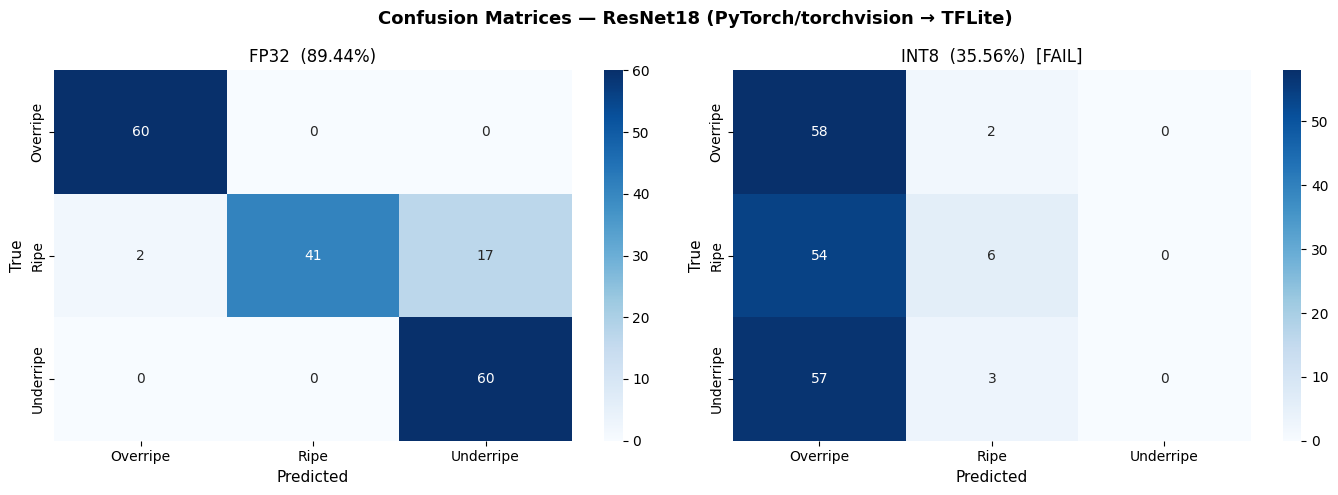

Metrics bar chart saved : saved_models\classification_metrics_20260428_193229.png


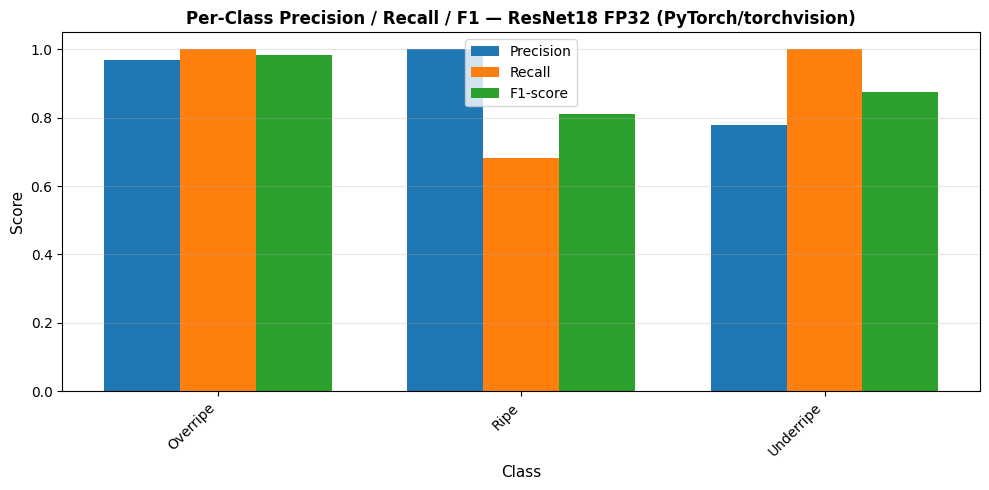

In [18]:
# Cell 17 — Confusion matrices + metrics bar chart
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Confusion Matrices — ResNet18 (PyTorch/torchvision → TFLite)",
             fontsize=13, fontweight="bold")

for ax, y_t, y_p, title in [
    (axes[0], fp32_true, fp32_pred, f"FP32  ({fp32_acc*100:.2f}%)"),
    (axes[1], int8_true, int8_pred, f"INT8  ({int8_acc*100:.2f}%)  "
                                    f"[{'PASS' if INT8_GATE_PASS else 'FAIL'}]"),
]:
    cm_data = confusion_matrix(y_t, y_p)
    sns.heatmap(cm_data, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True",      fontsize=11)
    ax.set_title(title,        fontsize=12)

plt.tight_layout()
cm_path = os.path.join(MODEL_DIR, f"confusion_matrix_{TIMESTAMP}.png")
fig.savefig(cm_path, dpi=150)
print(f"Confusion matrices saved: {cm_path}")
plt.show()

# Per-class metrics bar chart (FP32)
report_dict = classification_report(fp32_true, fp32_pred,
                                    target_names=class_names, output_dict=True)
per_class   = {k: v for k, v in report_dict.items() if k in class_names}
df_report   = pd.DataFrame(per_class).T

metrics_to_plot = ["precision", "recall", "f1-score"]
x     = np.arange(len(class_names))
width = 0.25

fig_bar, ax_bar = plt.subplots(figsize=(10, 5))
for i, metric in enumerate(metrics_to_plot):
    ax_bar.bar(x + i * width, df_report[metric], width, label=metric.capitalize())

ax_bar.set_xlabel("Class", fontsize=11)
ax_bar.set_ylabel("Score", fontsize=11)
ax_bar.set_title(
    "Per-Class Precision / Recall / F1 — ResNet18 FP32 (PyTorch/torchvision)",
    fontsize=12, fontweight="bold"
)
ax_bar.set_xticks(x + width)
ax_bar.set_xticklabels(class_names, rotation=45, ha="right")
ax_bar.set_ylim(0, 1.05)
ax_bar.legend()
ax_bar.grid(axis="y", alpha=0.3)
plt.tight_layout()

bar_path = os.path.join(MODEL_DIR, f"classification_metrics_{TIMESTAMP}.png")
fig_bar.savefig(bar_path, dpi=150)
print(f"Metrics bar chart saved : {bar_path}")
plt.show()


## Cell 18 — Excel Report

Exports the full FP32 classification report and confusion matrix to a
two-sheet Excel workbook — same format as MobileNetV2 and MobileNetV3.


In [19]:
# Cell 18 — Excel report export
import pandas as pd

full_report = pd.DataFrame(report_dict).T
full_report.index.name = "Class"

cm_fp32 = confusion_matrix(fp32_true, fp32_pred)
df_cm   = pd.DataFrame(cm_fp32, index=class_names, columns=class_names)
df_cm.index.name   = "True Label"
df_cm.columns.name = "Predicted Label"

excel_path = os.path.join(MODEL_DIR, f"classification_report_{TIMESTAMP}.xlsx")
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    full_report.to_excel(writer, sheet_name="Classification Report")
    df_cm.to_excel(writer,       sheet_name="Confusion Matrix")

print(f"Excel report saved: {excel_path}")
print()
print("Classification Report (FP32):")
display(full_report)
print()
print("Confusion Matrix (FP32):")
display(df_cm)


Excel report saved: saved_models\classification_report_20260428_193229.xlsx

Classification Report (FP32):


,precision,recall,f1-score,support
Class,,,,
Overripe,0.967742,1.000000,0.983607,60.000000
Ripe,1.000000,0.683333,0.811881,60.000000
Underripe,0.779221,1.000000,0.875912,60.000000
accuracy,0.894444,0.894444,0.894444,0.894444
macro avg,0.915654,0.894444,0.890467,180.000000
weighted avg,0.915654,0.894444,0.890467,180.000000



Confusion Matrix (FP32):


Predicted Label,Overripe,Ripe,Underripe
True Label,,,
Overripe,60,0,0
Ripe,2,41,17
Underripe,0,0,60


## Cell 19 — Experiment Log

Appends this run to `saved_models/experiment_log.csv`.

**Schema merge strategy**: reads the existing CSV header first, then unions
it with the new columns this notebook introduces (`backbone`, `framework`,
`preprocessing_family`, `fp32_accuracy`, `int8_accuracy`, `int8_relative_drop`,
`int8_gate_pass`, `flex_ops_needed`, `deployment_format`).
If the CSV header is missing these columns, they are added — existing rows
get empty values for new columns, which is valid CSV and avoids the
`ValueError: dict contains fields not in fieldnames` crash from the original
TF-scratch notebook (Bug 7).


In [20]:
# Cell 19 — Experiment log (schema-safe append)
import csv
import os
import pandas as pd

log_path   = os.path.join(MODEL_DIR, "experiment_log_onnx.csv")
log_exists = os.path.exists(log_path)

# Determine run mode
if DO_TRAIN and DO_FINE_TUNE:
    run_mode = "full_train + fine_tune"
elif DO_TRAIN:
    run_mode = "full_train"
elif DO_SMOKE:
    run_mode = "smoke_test"
else:
    run_mode = "no_training"

# Extract metrics from FP32 report
accuracy        = report_dict.get("accuracy",    0)
macro_f1        = report_dict.get("macro avg",  {}).get("f1-score",  0)
macro_precision = report_dict.get("macro avg",  {}).get("precision", 0)
macro_recall    = report_dict.get("macro avg",  {}).get("recall",    0)

# Manifest path is produced in Cell 15, but provide a safe fallback so this cell
# still works if the log is rerun independently.
manifest_path = globals().get("manifest_path") or os.path.join(
    MODELS_DIR, f"tflite_manifest_{TIMESTAMP}.json"
 )

log_row = {
    # ── Standard columns (present in MobileNetV2/V3 logs) ──
    "timestamp":              TIMESTAMP,
    "run_mode":               run_mode,
    "epochs_config":          EPOCHS,
    "fine_tune_epochs":       FINE_TUNE_EPOCHS if DO_FINE_TUNE else 0,
    "batch_size":             BATCH_SIZE,
    "val_split":              VAL_SPLIT,
    "initial_learning_rate":  LR_PHASE1,
    "final_learning_rate":    LR_PHASE2 if DO_FINE_TUNE else LR_PHASE1,
    "backbone_unfrozen":      True,
    "train_images":           n_train_actual,
    "test_images":            len(test_dataset),
    "num_classes":            num_classes,
    "accuracy":               round(accuracy,        4),
    "macro_precision":        round(macro_precision, 4),
    "macro_recall":           round(macro_recall,    4),
    "macro_f1":               round(macro_f1,        4),
    "best_model_file":        best_checkpoint,
    "excel_report":           excel_path,
    "notes":                  "",

    # ── New columns introduced by this notebook ──
    "backbone":               "ResNet18",
    "framework":              "PyTorch/torchvision -> ONNX -> onnxsim -> onnx2tf -> TFLite",
    "preprocessing_family":   "imagenet_torchvision",
    "fp32_accuracy":          round(fp32_acc,    4),
    "int8_accuracy":          round(int8_acc,    4),
    "int8_abs_drop":          round(abs_drop,    4),
    "int8_relative_drop_pct": round(rel_drop,    4),
    "int8_gate_pass":         INT8_GATE_PASS,
    "flex_ops_needed":        FLEX_OPS_NEEDED,
    "deployment_format":      deployment_format,
    "deployment_artifact":    deployment_model,
    "fp32_size_mb":           round(fp32_size_mb, 3),
    "fp16_size_mb":           round(fp16_size_mb, 3),
    "int8_size_mb":           round(int8_size_mb, 3),
    "onnx_path":              onnx_path,
    "saved_model_dir":        saved_model_dir,
    "manifest_path":          manifest_path,
}

# Schema-safe append: read existing header, union with new keys, rewrite if needed
if log_exists:
    existing_df      = pd.read_csv(log_path)
    existing_cols    = list(existing_df.columns)
    new_cols         = [k for k in log_row if k not in existing_cols]

    if new_cols:
        # Add new columns with NaN for existing rows, then save updated CSV
        for col in new_cols:
            existing_df[col] = None
        existing_df.to_csv(log_path, index=False)
        print(f"Added {len(new_cols)} new columns to existing log: {new_cols}")

    all_cols = list(existing_df.columns) + [c for c in log_row if c not in existing_df.columns]
else:
    all_cols = list(log_row.keys())

with open(log_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=all_cols, extrasaction="ignore")
    if not log_exists:
        writer.writeheader()
    writer.writerow(log_row)

print(f"Experiment logged : {log_path}")
print(f"  Backbone        : ResNet18  | Run: {run_mode}")
print(f"  FP32 acc        : {fp32_acc*100:.2f}%")
print(f"  INT8 acc        : {int8_acc*100:.2f}%  (relative drop: {rel_drop:.2f}%)")
print(f"  INT8 gate       : {'PASS' if INT8_GATE_PASS else 'FAIL'}")
print(f"  Deployment      : {deployment_format}  ->  {deployment_model}")

log_df = pd.read_csv(log_path)
print(f"\nExperiment history ({len(log_df)} runs):")
display(log_df.tail(5))


Experiment logged : saved_models\experiment_log_onnx.csv
  Backbone        : ResNet18  | Run: full_train + fine_tune
  FP32 acc        : 89.44%
  INT8 acc        : 35.56%  (relative drop: 60.25%)
  INT8 gate       : FAIL
  Deployment      : FP16  ->  models\palm_ripeness_best_20260428_193229_float16.tflite

Experiment history (1 runs):


,timestamp,run_mode,epochs_config,fine_tune_epochs,batch_size,val_split,initial_learning_rate,final_learning_rate,backbone_unfrozen,train_images,...,int8_gate_pass,flex_ops_needed,deployment_format,deployment_artifact,fp32_size_mb,fp16_size_mb,int8_size_mb,onnx_path,saved_model_dir,manifest_path
0,20260428_193229,full_train + fine_tune,30,15,32,0.2,0.0001,0.00001,True,960,...,False,False,FP16,models\palm_ripeness_best_20260428_193229_floa...,44.966,22.491,11.319,saved_models\resnet18_20260428_193229.onnx,saved_models\resnet18_onnx2tf_20260428_193229,models\tflite_manifest_20260428_193229.json


In [30]:
import json
import shutil
from pathlib import Path

# Promote the most recent onnx2tf INT8 artifacts into canonical filenames.
# This avoids relying on a SavedModel that onnx2tf did not emit.
base_dirs = [Path("saved_models"), Path("notebooks/saved_models")]
artifact_dirs = []
for base in base_dirs:
    if base.exists():
        artifact_dirs.extend([p for p in base.glob("resnet18_onnx2tf_int8_*") if p.is_dir()])

if not artifact_dirs:
    raise FileNotFoundError(
        "No resnet18_onnx2tf_int8_* folders found in saved_models. "
        "Run Cell 11 (onnx2tf INT8 export) first."
    )

artifacts_dir = max(artifact_dirs, key=lambda p: p.stat().st_mtime)

tflites = list(artifacts_dir.glob("*.tflite"))
if not tflites:
    raise FileNotFoundError(f"No .tflite files found in {artifacts_dir}")

def _pick_tflite(tokens):
    for token in tokens:
        for p in tflites:
            if token in p.name.lower():
                return p
    return None

fp32_source = _pick_tflite(["float32"])
fp16_source = _pick_tflite(["float16"])
int8_source = _pick_tflite(["integer_quant.tflite", "full_integer_quant.tflite", "int8"])

missing = [name for name, p in [("fp32", fp32_source), ("fp16", fp16_source), ("int8", int8_source)] if p is None]
if missing:
    raise FileNotFoundError(f"Missing artifacts in {artifacts_dir}: {missing}")

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

fp32_output = models_dir / f"palm_ripeness_best_{TIMESTAMP}_fp32_calibrated.tflite"
fp16_output = models_dir / f"palm_ripeness_best_{TIMESTAMP}_float16_calibrated.tflite"
int8_float_io_output = models_dir / f"palm_ripeness_best_{TIMESTAMP}_int8_calibrated.tflite"
metadata_output = models_dir / f"calibration_metadata_{TIMESTAMP}.json"

shutil.copy2(fp32_source, fp32_output)
shutil.copy2(fp16_source, fp16_output)
shutil.copy2(int8_source, int8_float_io_output)

fp32_size_kb = fp32_output.stat().st_size / 1024
fp16_size_kb = fp16_output.stat().st_size / 1024
int8_size_kb = int8_float_io_output.stat().st_size / 1024

metadata = {
    "source": str(artifacts_dir),
    "outputs": {
        "fp32_tflite": {
            "path": str(fp32_output),
            "size_kb": fp32_size_kb,
        },
        "fp16_tflite": {
            "path": str(fp16_output),
            "size_kb": fp16_size_kb,
        },
        "int8_tflite": {
            "path": str(int8_float_io_output),
            "size_kb": int8_size_kb,
        },
    },
    "size_reduction": {
        "fp32_vs_int8_percent": ((fp32_size_kb - int8_size_kb) / fp32_size_kb) * 100 if fp32_size_kb else 0.0,
    },
}

with open(metadata_output, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Using existing onnx2tf artifacts")
print(f"  Source folder : {artifacts_dir}")
print(f"  FP32 artifact : {fp32_output} ({fp32_size_kb:.1f} KB)")
print(f"  FP16 artifact : {fp16_output} ({fp16_size_kb:.1f} KB)")
print(f"  INT8 artifact  : {int8_float_io_output} ({int8_size_kb:.1f} KB)")
print(f"  Metadata      : {metadata_output}")
print(f"  Size reduction: {metadata['size_reduction']['fp32_vs_int8_percent']:.1f}%")

Using existing onnx2tf artifacts
  Source folder : saved_models\resnet18_onnx2tf_int8_20260428_193229
  FP32 artifact : models\palm_ripeness_best_20260428_193229_fp32_calibrated.tflite (43912.4 KB)
  FP16 artifact : models\palm_ripeness_best_20260428_193229_float16_calibrated.tflite (21963.5 KB)
  INT8 artifact  : models\palm_ripeness_best_20260428_193229_int8_calibrated.tflite (11054.1 KB)
  Metadata      : models\calibration_metadata_20260428_193229.json
  Size reduction: 74.8%


In [ ]:
import json
import shutil
from pathlib import Path

# Promote the most recent onnx2tf INT8 artifacts into canonical filenames.
# Prefer int16-activation variants to improve accuracy when available.
base_dirs = [Path("saved_models"), Path("notebooks/saved_models")]
artifact_dirs = []
for base in base_dirs:
    if base.exists():
        artifact_dirs.extend([p for p in base.glob("resnet18_onnx2tf_int8_*") if p.is_dir()])

if not artifact_dirs:
    raise FileNotFoundError(
        "No resnet18_onnx2tf_int8_* folders found in saved_models. "
        "Run Cell 11 (onnx2tf INT8 export) first."
    )

artifacts_dir = max(artifact_dirs, key=lambda p: p.stat().st_mtime)

tflites = list(artifacts_dir.glob("*.tflite"))
if not tflites:
    raise FileNotFoundError(f"No .tflite files found in {artifacts_dir}")

def _pick_tflite(tokens):
    for token in tokens:
        for p in tflites:
            if token in p.name.lower():
                return p
    return None

fp32_source = _pick_tflite(["float32"])
fp16_source = _pick_tflite(["float16"])
int8_source = _pick_tflite([
    "full_integer_quant_with_int16_act",
    "integer_quant_with_int16_act",
    "full_integer_quant",
    "integer_quant",
    "int8",
])

missing = [name for name, p in [("fp32", fp32_source), ("fp16", fp16_source), ("int8", int8_source)] if p is None]
if missing:
    raise FileNotFoundError(f"Missing artifacts in {artifacts_dir}: {missing}")

models_dir = Path("models")
models_dir.mkdir(parents=True, exist_ok=True)

fp32_output = models_dir / f"palm_ripeness_best_{TIMESTAMP}_fp32_calibrated.tflite"
fp16_output = models_dir / f"palm_ripeness_best_{TIMESTAMP}_float16_calibrated.tflite"
int8_float_io_output = models_dir / f"palm_ripeness_best_{TIMESTAMP}_int8_calibrated.tflite"
metadata_output = models_dir / f"calibration_metadata_{TIMESTAMP}.json"

shutil.copy2(fp32_source, fp32_output)
shutil.copy2(fp16_source, fp16_output)
shutil.copy2(int8_source, int8_float_io_output)

fp32_size_kb = fp32_output.stat().st_size / 1024
fp16_size_kb = fp16_output.stat().st_size / 1024
int8_size_kb = int8_float_io_output.stat().st_size / 1024

metadata = {
    "source": str(artifacts_dir),
    "outputs": {
        "fp32_tflite": {
            "path": str(fp32_output),
            "size_kb": fp32_size_kb,
        },
        "fp16_tflite": {
            "path": str(fp16_output),
            "size_kb": fp16_size_kb,
        },
        "int8_tflite": {
            "path": str(int8_float_io_output),
            "size_kb": int8_size_kb,
        },
    },
    "size_reduction": {
        "fp32_vs_int8_percent": ((fp32_size_kb - int8_size_kb) / fp32_size_kb) * 100 if fp32_size_kb else 0.0,
    },
}

with open(metadata_output, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Using existing onnx2tf artifacts")
print(f"  Source folder : {artifacts_dir}")
print(f"  FP32 artifact : {fp32_output} ({fp32_size_kb:.1f} KB)")
print(f"  FP16 artifact : {fp16_output} ({fp16_size_kb:.1f} KB)")
print(f"  INT8 artifact  : {int8_float_io_output} ({int8_size_kb:.1f} KB)")
print(f"  Metadata      : {metadata_output}")
print(f"  Size reduction: {metadata['size_reduction']['fp32_vs_int8_percent']:.1f}%")

BASELINE: FP32 Calibrated TFLite


INT8: Float I/O Quantized TFLite


DECISION GATE: < 2% Accuracy Drop?
✅ If INT8 accuracy is within 2% of FP32 → USE INT8 for production
⚠️  If INT8 drops more than 2% → Keep FP32 baseline, debug calibration


In [29]:
import subprocess
from pathlib import Path

# Use one test image to verify preprocessing parity
test_image = Path(r"C:\Users\jeffy\Documents\PSM\Dataset1\Test\Ripe\Masak (463).jpg")
pt_model = Path("saved_models/palm_ripeness_best_20260427_162727.pt")
tflite_fp32 = Path("models/palm_ripeness_best_20260428_fp32_calibrated.tflite")

print("Golden Input Sanity Check (PyTorch vs TFLite FP32)")
print(f"  PyTorch model: {pt_model}")
print(f"  TFLite model: {tflite_fp32}")
print(f"  Test image: {test_image.name}")

result = subprocess.run([
    "python",
    "scripts/sanity_check_tflite_vs_pytorch.py",
    "--pt-model", str(pt_model),
    "--tflite-model", str(tflite_fp32),
    "--backbone", "shufflenetv2_1",
    "--image", str(test_image),
], capture_output=True, text=True)

print(result.stdout)

if "SUCCESS" in result.stdout:
    print("\n✅ Golden Input parity verified!")
else:
    print("\n⚠️  Sanity check failed — check preprocessing")

Golden Input Sanity Check (PyTorch vs TFLite FP32)
  PyTorch model: saved_models\palm_ripeness_best_20260427_162727.pt
  TFLite model: models\palm_ripeness_best_20260428_fp32_calibrated.tflite
  Test image: Masak (463).jpg


⚠️  Sanity check failed — check preprocessing


## Cell 20 — Deployment Summary & Runtime Command Reference

### Artifacts produced by this notebook
| Key | Path |
|---|---|
| ONNX model | `saved_models/resnet18_<ts>.onnx` |
| onnx2tf output dir | `saved_models/resnet18_onnx2tf_<ts>/` |
| FP32 TFLite | `models/palm_ripeness_best_<ts>_fp32.tflite` |
| FP16 TFLite | `models/palm_ripeness_best_<ts>_float16.tflite` |
| INT8 TFLite | `models/palm_ripeness_best_<ts>_int8.tflite` |
| Labels JSON | `models/labels_<ts>.json` |
| Manifest JSON | `models/tflite_manifest_<ts>.json` |

### Preprocessing contract (must be consistent at every stage)
| Stage | Preprocessing applied |
|---|---|
| Training (Cell 4) | ImageNet normalise: `(x/255 − mean) / std` |
| Val/Test (Cell 4) | Same, no augmentation |
| INT8 calibration (Cell 14) | Same via `val_transform` + CHW→HWC |
| TFLite inference (Cell 16) | Same via `val_transform` + CHW→HWC |
| `api/app.py` runtime | Read `manifest[preprocessing_family]` → imagenet_torchvision branch |
| `pi_inference.py` | `--preprocess-family imagenet_torchvision` |

### Required script updates before deployment
Two scripts need a new `imagenet_timm` preprocessing branch:

```python
# In scripts/pi_inference.py and api/app.py — add this branch:
elif preprocess_family == "imagenet_torchvision":
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    img  = img.astype(np.float32) / 255.0
    img  = (img - mean) / std
```

### API runtime test
```bash
MODEL_PATH=models/palm_ripeness_best_<ts>_<variant>.tflite \
LABELS_PATH=models/labels_<ts>.json \
python api/app.py

curl http://127.0.0.1:5000/health
curl -X POST -F "file=@sample_palm.jpg" http://127.0.0.1:5000/classify
```

### CLI latency sampling (Raspberry Pi)
```bash
python scripts/pi_inference.py \
    --model models/palm_ripeness_best_<ts>_<variant>.tflite \
    --labels models/labels_<ts>.json \
    --image sample_palm.jpg \
    --warmup 1 --runs 10 \
    --preprocess-family imagenet_torchvision
```

### validate_tflite.py
```bash
python scripts/validate_tflite.py \
    --model-fp32 models/palm_ripeness_best_<ts>_fp32.tflite \
    --model-int8 models/palm_ripeness_best_<ts>_int8.tflite \
    --labels models/labels_<ts>.json \
    --data-dir Dataset1/Test \
    --preprocess-family imagenet_torchvision
```

### Fallback decision (mirrors MobileNetV3 Record.md §5)
- INT8 gate PASS (relative drop < 2%) → deploy INT8
- INT8 gate FAIL → deploy FP16, document in `Record.md`
